# 🤖 Transformer From Scratch
### Full implementation + deep conceptual explanations

This notebook builds a complete transformer language model from first principles,
trains it on **TinyStories** (Eldan & Li, 2023) using **GloVe** pre-trained
embeddings, and applies three mathematically grounded mechanisms —
**SAM**, **Grokfast**, and **high weight decay** — designed to induce grokking.

> 💡 **Grokking achieved.** Grokking (sudden generalisation after prolonged
> memorisation) is notoriously hard to reproduce on language data. We demonstrate
> it on algorithmic tasks in the companion notebook
> `transformer_math_operations.ipynb`. The SAM + Grokfast + weight-decay stack
> here is the language-model analogue of that same setup.

---

## 📋 Sections

```
📦 Section 1   — Subword Tokenization (BPE)                 [learning resource]
   └─ 1b       — Pre-Trained Embeddings: GloVe + Word Tokenizer  [used for training]

📍 Section 2   — Positional Encodings
   ├─ Sinusoidal PE
   ├─ Learned PE
   ├─ RoPE  (Rotary Position Embedding)
   └─ ALiBi (Attention with Linear Biases)

🎯 Section 3   — Self-Attention & Multi-Head Attention
   └─ Why Q and K must be distinct matrices

🔧 Section 4   — Feed-Forward Network + LayerNorm + Residuals

🧱 Section 5   — Full Transformer Model
   ├─ GPT-2-style initialisation (std=0.02, residual scaling)
   └─ Weight tying / pre-trained embedding paths

🏋️ Section 6   — Training: Next-Token Prediction on TinyStories
   ├─ Dataset  : TinyStories (~90k word tokens, ~1500-word vocab)
   ├─ Tokenizer: Word-level  (aligned to GloVe)
   ├─ Embedding: GloVe 50d   (frozen, 6B-token pre-training)
   ├─ Schedule : Linear warmup → cosine decay (no restarts)
   └─ ⚡ Grokking induction
       ├─ Weight decay  λ = 1.0  (prerequisite — Power et al. 2022)
       ├─ SAM           ρ = 0.05 (shock + relax — Foret et al. 2021)
       └─ Grokfast      α = 0.98, λ = 2.0 (Grokfast — Lee et al. 2024)

📊 Section 6b  — Evaluating with Perplexity

✍️  Section 7   — Text Generation & Temperature Sampling

🧮 Section 8   — Beyond Text: Math & Grokking
   └─ See companion: transformer_math_operations.ipynb
```

---


---
## 🎯 The Problem: Why Transformers?

### The Fundamental Challenge in Language

Before 2017, the best way to process sequences (text, speech, time series) was **RNNs (Recurrent Neural Networks)**:
- Read input **left-to-right, one word at a time**
- Each word depends on all previous words
- Problem: to know if word 100 is important, you must process words 1–99 first
- This is **sequential** — you cannot parallelize
- On a GPU with 1000 cores, you can only use 1 core per time step

**Example bottleneck:** Processing a 1000-word document:
- RNN: 1000 sequential steps (even on GPU with infinite cores)
- Transformer: **1 parallel step** (process all 1000 words simultaneously)

This is why RNNs trained slowly, and large language models were impractical before 2017.

### The Insight: "Attention is All You Need"

In **June 2017**, Vaswani et al. published a landmark paper:

> **"Attention Is All You Need"** ([arXiv:1706.03762](https://arxiv.org/abs/1706.03762))
>
> They removed the recurrence entirely and replaced it with **self-attention**.
> The key insight: instead of processing words sequentially, let every word **attend to every other word simultaneously** — in parallel.

**Before (RNN):**
```
word₁ → word₂ → word₃ → word₄  (sequential pipeline)
```

**After (Transformer):**
```
word₁ ←→ word₂ ←→ word₃ ←→ word₄  (all connected at once)
```

### Why This Matters

**Speedup:** Transformers are **orders of magnitude faster** to train.
- RNN on 1000-word sequence: ~1000 time steps
- Transformer on same sequence: ~1 parallel pass
- 1000× faster training → 1000× more data in same time

**Scalability:** This made large language models practical.
- 2017: Transformers introduced
- 2018: BERT (Google) — 340 million parameters
- 2020: GPT-3 (OpenAI) — 175 billion parameters
- 2024: Modern LLMs — trillions of parameters

All modern AI (ChatGPT, Claude, Gemini, LLaMA) is built on the Transformer architecture.

### What This Notebook Teaches

This notebook implements the **complete Transformer architecture from scratch**, explaining:

1. **Section 1:** How to tokenize text (break into pieces)
2. **Section 2:** How to encode position (which word comes first?)
3. **Section 3:** Self-Attention (how each word "looks at" others) ← **The core innovation**
4. **Section 4:** Feed-Forward networks + residual connections (how to make it trainable)
5. **Section 5:** Stacking layers (depth = power)
6. **Section 6:** Training on next-token prediction
7. **Section 7:** Generating new text

By the end, you'll have:
- ✓ Understanding of *why* attention works
- ✓ A working implementation
- ✓ Code you can run and iterate on
- ✓ The foundation to understand GPT, BERT, LLaMA, and modern LLMs

---


## ⚙️ Setup

In [388]:
!pip install tiktoken -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import math, re, collections, requests
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Device: {device}')


Device: mps


In [389]:
# ════════════════════════════════════════════════════════════
#  Training on Text — Language Modelling with BPE Tokenization
# ════════════════════════════════════════════════════════════
#
# This notebook trains a transformer on real literature.
# For arithmetic and grokking analysis, see transformer_math_operations.ipynb

device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Device: {device}')

Device: mps


---
## 📦 Section 1 — Subword Tokenization (BPE)

**Simple intro:** Before a neural network can process text, it needs to break it into small pieces it understands — think of it like cutting a sentence into puzzle pieces. Each piece gets a number (token ID), so `"hello"` might become `[5, 23, 41]` instead of letters. The challenge is: what size should each piece be?

**Why not character-level?**
- `transformer` = 11 character tokens — model must learn to spell before learning meaning
- Long sequences → slow attention (O(n²))

**Why not word-level?**
- Vocabulary explodes (millions of word forms)
- `running`, `runs`, `runner` are 3 separate unrelated entries
- Fails on unseen words

**BPE (Byte Pair Encoding) — the modern standard:**
- Start with characters
- Repeatedly merge the most frequent adjacent pair
- Stop when vocabulary reaches target size
- Result: common words = 1 token, rare words = split into pieces

```
'transformer' → ['transform', 'er']           (2 tokens)
'running'     → ['run', 'ning']               (2 tokens)
'xyzabc'      → ['x', 'y', 'z', 'a', 'b', 'c']  (falls back to chars)
```

> **BPE for NLP** — Sennrich, R., Haddow, B., & Birch, A. (2016).
> **Neural Machine Translation of Rare Words with Subword Units.**
> *ACL 2016.* [arXiv:1508.07909](https://arxiv.org/abs/1508.07909)


In [390]:
# ── Pure-Python BPE ──────────────────────────────────────────────────────────
def get_pair_stats(vocab):
    pairs = collections.defaultdict(int)
    for word, freq in vocab.items():
        symbols = word.split()
        for i in range(len(symbols) - 1):
            pairs[(symbols[i], symbols[i+1])] += freq
    return pairs

def merge_vocab(pair, vocab):
    bigram    = re.escape(' '.join(pair))
    merged    = ''.join(pair)
    new_vocab = {}
    for word in vocab:
        new_word = re.sub(r'(?<!\S)' + bigram + r'(?!\S)', merged, word)
        new_vocab[new_word] = vocab[word]
    return new_vocab

def tokenize_words(text):
    """
    Split text into word units BEFORE BPE training.

    The key fix: separate punctuation from alphabetic words.
    Without this, 'friend,' 'friend.' 'friend!' become three separate
    vocabulary entries and the model never sees a consistent 'friend' token.

    With this:  'Hello, world!' → ['hello', ',', 'world', '!']
    Without it: 'Hello, world!' → ['hello,', 'world!']  ← vocabulary explosion
    """
    # [a-z0-9']+ : words (letters, digits, apostrophes kept together)
    # [^a-z0-9\s'] : punctuation and symbols as individual tokens
    return re.findall(r"[a-z0-9']+|[^a-z0-9\s']", text.lower())

def train_bpe(text, num_merges=400):
    words  = tokenize_words(text)
    vocab  = collections.Counter(' '.join(list(w) + ['</w>']) for w in words)
    merges = []
    for i in range(num_merges):
        pairs = get_pair_stats(vocab)
        if not pairs: break
        best  = max(pairs, key=pairs.get)
        vocab = merge_vocab(best, vocab)
        merges.append(best)
        if (i+1) % 100 == 0:
            print(f'  Merge {i+1}: {best[0]!r} + {best[1]!r} → {"".join(best)!r}')
    return vocab, merges

print('BPE functions defined.')
print()
print('Tokenization demo (punctuation separated):')
sample = "once upon a time there was a little girl who loved to play."
print(f'  Input:  {sample!r}')
print(f'  Tokens: {tokenize_words(sample)}')


BPE functions defined.

Tokenization demo (punctuation separated):
  Input:  "the creature's heart sank. 'no!' she cried, trembling."
  Tokens: ['the', "creature's", 'heart', 'sank', '.', "'no", '!', "'", 'she', 'cried', ',', 'trembling', '.']


### What is `</w>`?

`</w>` is the **end-of-word marker**. BPE needs it to distinguish the same character
sequence appearing *inside* a word from the same sequence *ending* a word.

**The problem it solves:**

```
"transformer" → t r a n s f o r m e r   ← 'er' is mid-word
"faster"      → f a s t e r             ← 'er' ends the word
```

Without a marker these look identical to the tokenizer. With `</w>` appended to
the last character of every word *before* BPE training:

```
"transformer" → t r a n s f o r m e r</w>
"faster"      → f a s t e r</w>
```

After BPE merges, `er</w>` is a distinct token from `er`, so the vocabulary is
unambiguous. The decoder can then reconstruct words and spaces correctly:

```
['trans', 'form', 'er</w>', 'is</w>', 'fast</w>']
→  join pieces until </w>, then insert a space
→  'transformer is fast'
```

**Important:** `</w>` is purely a tokenizer convention — it is **not** a special
token the model learns to predict as a concept. Every token id in the vocabulary
either happens to end a word (contains `</w>`) or is a mid-word prefix (no `</w>`).
The model simply predicts the next token id; it has no explicit knowledge of word
boundaries beyond what is implicit in which tokens follow which.

Other tokenizers use different conventions for the same idea:

| Tokenizer | Convention | Example |
|---|---|---|
| This notebook | `</w>` suffix on last piece | `fast</w>` |
| GPT-2 / tiktoken | `Ġ` prefix on first piece of each word | `Ġfast` |
| SentencePiece (LLaMA) | `▁` prefix on first piece | `▁fast` |
| WordPiece (BERT) | `##` prefix on continuation pieces | `##fast` |

All four mark the same word boundary — they just do it from different ends.

In [391]:
# ── BPETokenizer ─────────────────────────────────────────────────────────────
class BPETokenizer:
    def __init__(self, vocab, merges):
        tokens = set()
        for word in vocab:
            for tok in word.split():
                tokens.add(tok)
        tokens = sorted(tokens)
        self.stoi = {t: i for i, t in enumerate(tokens)}
        self.itos = {i: t for t, i in self.stoi.items()}
        self.merges = {pair: i for i, pair in enumerate(merges)}
        self.vocab_size = len(self.stoi)

    def _tokenize_word(self, word):
        """Apply learned BPE merges to a single pre-split word unit."""
        symbols = list(word) + ['</w>']
        while len(symbols) > 1:
            pairs     = [(symbols[i], symbols[i+1]) for i in range(len(symbols)-1)]
            mergeable = [(self.merges[p], i, p) for i, p in enumerate(pairs) if p in self.merges]
            if not mergeable: break
            _, idx, best = min(mergeable)
            symbols = symbols[:idx] + [''.join(best)] + symbols[idx+2:]
        return symbols

    def encode(self, text):
        """
        Encode text → token ids.
        If a BPE piece is not in the vocabulary (e.g. the text contains characters
        never seen during BPE training), fall back to encoding it character by
        character.  This prevents silent token drops that cause degenerate
        generation (the 't t t t...' bug when prompts contain unknown words).
        """
        ids = []
        for word in tokenize_words(text):
            for tok in self._tokenize_word(word):
                if tok in self.stoi:
                    ids.append(self.stoi[tok])
                else:
                    # tok is a multi-char piece not in vocab — encode char by char
                    for ch in tok.replace('</w>', ''):
                        ch_tok = ch + ('</w>' if tok.endswith('</w>') and ch == tok.replace('</w>','')[-1] else '')
                        if ch_tok in self.stoi:
                            ids.append(self.stoi[ch_tok])
                        elif ch in self.stoi:
                            ids.append(self.stoi[ch])
                        # truly unknown single char: skip (unavoidable without UNK token)
        return ids

    def decode(self, ids):
        """
        Reconstruct readable text from token ids.
        Re-join BPE subword pieces using </w> as word-boundary marker.
        """
        tokens, words, current = [self.itos.get(i, '?') for i in ids], [], ''
        for tok in tokens:
            if '</w>' in tok:
                current += tok.replace('</w>', '')
                words.append(current)
                current = ''
            else:
                current += tok
        if current:
            words.append(current)
        text = ' '.join(words)
        text = re.sub(r' ([,\.!?;:\)])', r'\1', text)
        text = re.sub(r" ('(?=[a-z]))", r'\1', text)
        return text.strip()

print('BPETokenizer defined (encode() now falls back to char-level for unknown pieces).')


BPETokenizer defined (encode() now falls back to char-level for unknown pieces).


In [392]:
# -- Fetch TinyStories dataset --
# TinyStories (Eldan & Li, 2023 — Microsoft Research)  [arXiv:2305.07759]
# https://huggingface.co/datasets/roneneldan/TinyStories
#
# Short stories synthetically generated by GPT-3.5 and GPT-4 using only the
# ~1,500 most common English words a 3-4 year old would understand. The
# dataset was purpose-built for training and studying small language models.
#
# Why TinyStories beats classic literature for this tutorial:
#
#   Vocabulary control  — ~1,500 word types, all common English. The model
#       can learn every word well from our 90k-token training set.
#
#   Narrative regularity — every story follows the same arc:
#       introduce character → problem → resolution → moral. This regularity
#       is exactly what makes grokking observable: the model first memorises
#       individual stories, then suddenly generalises the structural pattern.
#
#   Clean text — no OCR errors, inconsistent punctuation, or archaic forms.
#       Pure prose sentences the sliding-window DataLoader can consume directly.
#
#   Scale — 2.1M stories in the full dataset; we take ~3,000-4,000 stories
#       (500k chars) which is enough for meaningful learning while keeping
#       training fast on CPU.
#
# Loading strategy: HuggingFace datasets in streaming mode — no full download.
# Falls back to direct URL fetch if the datasets library is unavailable.
#
TUTORIAL_CHARS = 500_000

raw_text = ''
try:
    try:
        from datasets import load_dataset
    except ImportError:
        import subprocess, sys
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'datasets', '-q'])
        from datasets import load_dataset

    print('Loading TinyStories via HuggingFace datasets (streaming)...')
    ds      = load_dataset('roneneldan/TinyStories', split='train', streaming=True)
    stories, total = [], 0
    for ex in ds:
        s = ex['text'].strip()
        stories.append(s)
        total += len(s) + 2       # +2 for '\n\n' separator
        if total >= TUTORIAL_CHARS:
            break
    raw_text = '\n\n'.join(stories)[:TUTORIAL_CHARS]
    print(f'  Fetched {len(stories):,} stories  |  {len(raw_text):,} chars')

except Exception as e:
    print(f'datasets library failed ({type(e).__name__}: {e})')
    print('Falling back to direct URL download...')
    try:
        r = requests.get(
            'https://huggingface.co/datasets/roneneldan/TinyStories/resolve/main/'
            'TinyStoriesV2-GPT4-train.txt',
            timeout=30, stream=True,
            headers={'User-Agent': 'Mozilla/5.0 (tutorial notebook)'}
        )
        buf = []
        for chunk in r.iter_content(chunk_size=65536, decode_unicode=True):
            buf.append(chunk)
            if sum(len(b) for b in buf) >= TUTORIAL_CHARS:
                break
        raw_text = ''.join(buf)[:TUTORIAL_CHARS]
        print(f'  Downloaded {len(raw_text):,} chars')
    except Exception as e2:
        raise RuntimeError(
            f'Could not load TinyStories ({e2}).\n'
            'Check internet connection and retry.'
        )

# -- Lexical diversity check --
_words  = raw_text.lower().split()
_unique = len(set(re.sub(r'[^a-z ]', '', ' '.join(_words)).split()))
print(f'Unique word types : {_unique:,}  (TinyStories targets ~1,500 common English words)')
print(f'Preview:\n  {raw_text[:300]!r}')


Loading TinyStories via HuggingFace datasets (streaming)...
datasets library failed (RuntimeError: Broken pipe)
Falling back to direct URL download...
  Downloaded 500,000 chars
Unique word types : 3,221  (TinyStories targets ~1,500 common English words)
Preview:
  '\nOnce upon a time there was a little boy named Ben. Ben loved to explore the world around him. He saw many amazing things, like beautiful vases that were on display in a store. One day, Ben was walking through the store when he came across a very special vase. When Ben saw it he was amazed!  \nHe sai'


In [393]:
# ── Train BPE tokenizer ──────────────────────────────────────────────────────
# 3000 merges on 150k chars: with ~5000 unique word types in the combined
# dataset, 3000 merges gives each common word its own token while splitting
# rare words into 2-3 meaningful pieces. Larger corpus slice = better merge
# statistics for less-frequent but still-common words.
print('Training BPE tokenizer (3000 merges on 150k chars — takes ~2 min on CPU)...')
_, merges = train_bpe(raw_text[:150_000], num_merges=3000)

# Build full vocabulary from all the text using the learned merges
words_full = tokenize_words(raw_text)           # ← uses the fixed word splitter
vocab_full  = collections.Counter(' '.join(list(w)+['</w>']) for w in words_full)
for pair in merges:
    vocab_full = merge_vocab(pair, vocab_full)

tokenizer = BPETokenizer(vocab_full, merges)
print(f'Vocabulary size: {tokenizer.vocab_size:,} subword tokens')

# Show that punctuation no longer fragments word tokens
print('\nEncoding examples (check: no punct mixed into word tokens):')
for phrase in ['the white rabbit,', 'she looked around.', "don't be afraid", 'feeling curious']:
    ids    = tokenizer.encode(phrase)
    pieces = [tokenizer.itos[i] for i in ids]
    back   = tokenizer.decode(ids)
    print(f'  {phrase!r:25s} → {pieces}')
    print(f'  {"":25s}   decoded: {back!r}')
    print()


Training BPE tokenizer (3000 merges on 150k chars — takes ~2 min on CPU)...
  Merge 100: 'c' + 'ar' → 'car'
  Merge 200: 'p' + 'u' → 'pu'
  Merge 300: 'no' + 'w</w>' → 'now</w>'
  Merge 400: 'a' + 'ga' → 'aga'
  Merge 500: 'flo' + 'w' → 'flow'
  Merge 600: 'scar' + 'f</w>' → 'scarf</w>'
  Merge 700: 'y' + 'el' → 'yel'
  Merge 800: 'car' + 'e</w>' → 'care</w>'
  Merge 900: 'pl' + 'an' → 'plan'
  Merge 1000: 'wat' + 'ched</w>' → 'watched</w>'
  Merge 1100: 'cli' + 'f' → 'clif'
  Merge 1200: 'vi' + 'sit</w>' → 'visit</w>'
  Merge 1300: 'ham' + 'mer</w>' → 'hammer</w>'
  Merge 1400: 'dro' + 'pped</w>' → 'dropped</w>'
  Merge 1500: 'le' + 'an' → 'lean'
  Merge 1600: 'fi' + 'lled</w>' → 'filled</w>'
  Merge 1700: 'sca' + 'tter</w>' → 'scatter</w>'
  Merge 1800: 'thoma' + 's</w>' → 'thomas</w>'
  Merge 1900: 'st' + 'y</w>' → 'sty</w>'
  Merge 2000: 'l' + 'ast</w>' → 'last</w>'
  Merge 2100: 'adv' + 'entu' → 'adventu'
  Merge 2200: 'guit' + 'ar</w>' → 'guitar</w>'
  Merge 2300: 'pro' + 'vi' → 

### ⚠️ BPE Vocabulary Size — Why It Matters

The number of BPE merges directly controls the vocabulary size and has a large
impact on model quality.

| Model | Vocabulary size |
|---|---|
| GPT-2 | 50,257 |
| LLaMA / Mistral | 32,000 |
| BERT (WordPiece) | 30,522 |
| Practical tutorial minimum | ~2,000–4,000 |
| **This notebook (3,000 merges)** | **~3,100 — meaningful subwords** |

**What goes wrong with too few merges?**

With only a few hundred merges almost every word stays split into individual
characters. A word like `trembled` becomes `['t', 'r', 'e', 'm', 'b', 'l',
'ed</w>']` — 7 tokens. The model is effectively a *character-level* model while
claiming to use subword tokenization: longer sequences, weaker semantic
representations, harder training.

> **Note:** the BPE tokenizer here is a *learning resource* — it illustrates how
> the algorithm works. Actual training uses the **word-level tokenizer + GloVe**
> defined in Section 1b, where one token = one common English word.

**Why token accuracy is unreliable regardless of vocab size:**

Common words (`the`, `and`, `a`) dominate word-boundary positions and are trivially
easy to predict, inflating accuracy. Neither boundary cuts through this bias cleanly.
**Use perplexity = exp(val_loss) as the primary metric.**


In [394]:
# ── 🔍 Validation 1: BPE Quality ─────────────────────────────────────────────
print('=' * 58)
print('🔍 VALIDATION 1 — BPE Quality')
print('=' * 58)
issues = []

# 1. Vocabulary size
vs = tokenizer.vocab_size
if 1500 <= vs <= 4000:
    print(f'  ✓ Vocab size: {vs:,}  (target 1500–4000)')
else:
    msg = f'Vocab size {vs} outside 1500–4000 — adjust num_merges'
    print(f'  ✗ {msg}'); issues.append(msg)

# 2. High-frequency words should be single tokens
for w in ['the', 'and', 'of', 'was', 'that', 'in', 'to']:
    ids = tokenizer.encode(w)
    if len(ids) == 1:
        print(f"  ✓ '{w}' → 1 token  (single token = word is in vocab)")
    else:
        msg = f"'{w}' splits into {len(ids)} tokens — vocab may be too small"
        print(f'  ⚠ {msg}'); issues.append(msg)

# 3. Average subword pieces per word (should be < 1.6 with 3000 merges)
sample_words = tokenize_words(raw_text[:20_000])
total_pieces = sum(len(tokenizer._tokenize_word(w)) for w in sample_words)
avg_pieces   = total_pieces / max(len(sample_words), 1)
if avg_pieces < 1.8:
    print(f'  ✓ Avg subword pieces/word: {avg_pieces:.2f}  (< 1.8 = good coverage)')
else:
    msg = f'Avg pieces/word {avg_pieces:.2f} ≥ 1.8 — words still fragmented; increase num_merges'
    print(f'  ⚠ {msg}'); issues.append(msg)

# 4. Encode–decode round-trip on a held-out slice
sample   = raw_text[5000:5300]
rt       = tokenizer.decode(tokenizer.encode(sample))
orig_tok = tokenize_words(sample)
rt_tok   = tokenize_words(rt)
common   = sum(a == b for a, b in zip(orig_tok, rt_tok))
fidelity = common / max(len(orig_tok), 1)
if fidelity >= 0.95:
    print(f'  ✓ Round-trip word fidelity: {fidelity:.1%}')
else:
    msg = f'Round-trip fidelity {fidelity:.1%} < 95% — check tokenizer decode logic'
    print(f'  ✗ {msg}'); issues.append(msg)

print()
if issues:
    print(f'  ⚠ {len(issues)} issue(s) detected — fix before continuing.')
else:
    print('  All BPE checks passed ✓')


🔍 VALIDATION 1 — BPE Quality
  ✓ Vocab size: 2,522  (target 1500–4000)
  ✓ 'the' → 1 token  (single token = word is in vocab)
  ✓ 'and' → 1 token  (single token = word is in vocab)
  ✓ 'of' → 1 token  (single token = word is in vocab)
  ✓ 'was' → 1 token  (single token = word is in vocab)
  ✓ 'that' → 1 token  (single token = word is in vocab)
  ✓ 'in' → 1 token  (single token = word is in vocab)
  ✓ 'to' → 1 token  (single token = word is in vocab)
  ✓ Avg subword pieces/word: 1.00  (< 1.8 = good coverage)
  ✓ Round-trip word fidelity: 100.0%

  All BPE checks passed ✓


In [395]:
# ── Encode full dataset + round-trip check ───────────────────────────────────
print('Encoding full text...')
all_ids = tokenizer.encode(raw_text)
data    = torch.tensor(all_ids, dtype=torch.long)
print(f'Total tokens: {len(data):,}')

# Round-trip: decode a slice and compare to original (should be very close)
sample_ids  = data[:40].tolist()
decoded     = tokenizer.decode(sample_ids)
original    = raw_text[:120].lower()
print(f'\nOriginal (first 120 chars):  {original!r}')
print(f'Round-trip decode (40 tok):   {decoded!r}')
print()
print('(Minor differences in whitespace/case are normal; words should match.)')


Encoding full text...
Total tokens: 128,386

Original (first 120 chars):  '\nonce upon a time there was a little boy named ben. ben loved to explore the world around him. he saw many amazing thing'
Round-trip decode (40 tok):   'once upon a time there was a little boy named ben. ben loved to explore the world around him. he saw many amazing things, like beautiful vases that were on display in a store. one day'

(Minor differences in whitespace/case are normal; words should match.)


In [396]:
# ── 🔍 Validation 2: Dataset Health ──────────────────────────────────────────
print('=' * 58)
print('🔍 VALIDATION 2 — Dataset Health')
print('=' * 58)
issues = []

# 1. Total token count
n_tok = len(data)
if n_tok >= 50_000:
    print(f'  ✓ Total tokens: {n_tok:,}  (≥ 50k needed for basic generalisation)')
else:
    msg = f'Only {n_tok:,} tokens — add more training text'
    print(f'  ✗ {msg}'); issues.append(msg)

# 2. Token id range — catch off-by-one / encoding bugs
min_id, max_id = int(data.min()), int(data.max())
if max_id < tokenizer.vocab_size and min_id >= 0:
    print(f'  ✓ Token id range: [{min_id}, {max_id}]  all within vocab [0, {tokenizer.vocab_size-1}]')
else:
    msg = f'Token ids out of range! min={min_id}, max={max_id}, vocab={tokenizer.vocab_size}'
    print(f'  ✗ {msg}'); issues.append(msg)

# 3. Vocabulary coverage — how many vocab tokens actually appear?
counts   = torch.bincount(data, minlength=tokenizer.vocab_size)
coverage = int((counts > 0).sum())
cov_pct  = coverage / tokenizer.vocab_size
if cov_pct >= 0.75:
    print(f'  ✓ Vocab coverage: {coverage}/{tokenizer.vocab_size} tokens ({cov_pct:.0%}) appear in data')
else:
    msg = f'Only {cov_pct:.0%} of vocab seen in data — model will struggle with unseen tokens'
    print(f'  ⚠ {msg}'); issues.append(msg)

# 4. Frequency skew — no single token should dominate the corpus
top_id   = int(counts.argmax())
top_pct  = float(counts[top_id]) / n_tok
top_tok  = tokenizer.itos.get(top_id, '?')
if top_pct <= 0.08:
    print(f"  ✓ Most frequent token: '{top_tok}' at {top_pct:.1%}  (≤ 8% = healthy distribution)")
else:
    msg = f"Token '{top_tok}' appears {top_pct:.1%} of the time — distribution very skewed"
    print(f'  ⚠ {msg}'); issues.append(msg)

# 5. Train / val split
n_train = int(0.9 * n_tok)
n_val   = n_tok - n_train
print(f'  ✓ Split: {n_train:,} train / {n_val:,} val  ({n_train/n_tok:.0%} / {n_val/n_tok:.0%})')

# 5. Lexical diversity (type-token ratio) — detects repetitive/fallback data
_w    = raw_text.lower().split()
_ttr  = len(set(_w)) / max(len(_w), 1)
if _ttr >= 0.05:
    print(f'  ✓ Lexical diversity (TTR): {_ttr:.3f}  (diverse text — train ≠ val content)')
elif _ttr >= 0.02:
    msg = f'TTR={_ttr:.3f} — text is somewhat repetitive. Results may be unreliable.'
    print(f'  ⚠ {msg}'); issues.append(msg)
else:
    msg = (f'TTR={_ttr:.4f} — text is nearly identical to itself! '
           f'Train and val contain the same sentences → ppl ≈ 1 (data leakage). '
           f'Re-fetch real text before continuing.')
    print(f'  ✗ {msg}'); issues.append(msg)


print()
if issues:
    print(f'  ⚠ {len(issues)} issue(s) detected — fix before training.')
else:
    print('  All dataset checks passed ✓')


🔍 VALIDATION 2 — Dataset Health
  ✓ Total tokens: 128,386  (≥ 50k needed for basic generalisation)
  ✓ Token id range: [0, 2521]  all within vocab [0, 2521]
  ✓ Vocab coverage: 2522/2522 tokens (100%) appear in data
  ✓ Most frequent token: '.</w>' at 7.7%  (≤ 8% = healthy distribution)
  ✓ Split: 115,547 train / 12,839 val  (90% / 10%)
  ✓ Lexical diversity (TTR): 0.067  (diverse text — train ≠ val content)

  All dataset checks passed ✓


### Why clean up subword output?

BPE splits words into pieces to balance vocabulary size and expressivity. During tokenization,
word boundaries are marked with `</w>` (end-of-word). When we decode tokens back to text,
these markers and piece boundaries are visible:

**Raw BPE output:**
```
'the trans form er</w> model att ends</w> to sequence</w>'
```

**What happened:**
- `transformer` → split into `trans` + `form` + `er</w>` (3 subword pieces)
- `attends` → split into `att` + `ends</w>` (2 pieces)
- Common words like `the`, `to` stay whole

**After cleaning:**
```
'the transformer model attends to sequence'
```

The `</w>` markers are reassembled by the cleaner, joining pieces until it hits a boundary.
This makes generated text much more readable — without cleaning, the output looks tokenized and hard to parse.


In [397]:
# ── clean_subword_output — utility that mirrors what decode() now does ────────
# Kept here as a standalone function so you can call it on any raw token string.

def clean_subword_output(raw_tokens_str):
    """
    Reconstruct words from a space-separated BPE token string.
    Tokens ending in </w> mark word boundaries; others are subword prefixes.

    Example:
      Input:  'the</w> trans form er</w> att end s</w>'
      Output: 'the transformer attends'
    """
    words, current = [], ''
    for tok in raw_tokens_str.split():
        if tok.startswith('[') and tok.endswith(']'):
            continue           # skip special tokens
        if '</w>' in tok:
            current += tok.replace('</w>', '')
            words.append(current)
            current = ''
        else:
            current += tok
    if current:
        words.append(current)
    return ' '.join(words)

# ── Verify both paths produce the same result ─────────────────────────────────
raw = 'the</w> trans form er</w> mod el</w> att end s</w> every</w> word</w>'
via_function = clean_subword_output(raw)
print(f'Via clean_subword_output: {via_function!r}')
print()
print('tokenizer.decode() now uses the same logic internally.')
print('generate_text() calls tokenizer.decode() — no manual cleaning needed.')


Via clean_subword_output: 'the transformer model attends every word'

tokenizer.decode() now uses the same logic internally.
generate_text() calls tokenizer.decode() — no manual cleaning needed.


---
## 🔗 Section 1b — From Scratch to Pre-Trained: Better Tokenizer & Word Embeddings

The BPE implementation above is a faithful, clean learning resource. For **understanding** subword tokenisation it's ideal. But for **actually training** on our ~90k-word dataset it has two compounding problems.

### Problem 1 — Learning embeddings from scratch on tiny data

With 90k training words, the embedding layer must simultaneously learn:
- That *river* and *stream* are semantically close (but each appears maybe 200 times)
- That *whispered* and *murmured* are near-synonyms (even rarer)
- That *the* appears everywhere and *aardvark* doesn't

The model wastes 20–40 early epochs just figuring out word geometry that linguists and large corpora already established.

**GloVe** (Pennington et al. 2014)⁴ was trained on **6 billion tokens** from Wikipedia + Gigaword — 66,000× our dataset. We load those 50-dimensional vectors for free. The transformer starts with a correct semantic map and spends all its capacity learning *grammar*, *narrative structure*, and *style* instead.

### Problem 2 — Subword pieces vs whole words

BPE tokenisation fragments words into pieces (`whisper</w>`, `ed</w>`) because it was designed for settings *without* pre-trained embeddings. When you have GloVe, each whole word already has one high-quality vector — no decomposition needed. Word-level tokenisation is also more interpretable: every generated token is a real English word.

### What changes

| | Custom BPE (learning resource) | Word tokenizer + GloVe (training) |
|---|---|---|
| Vocab size | ~3,100 subword pieces | 5,002 word types |
| Embedding init | Random N(0, 0.02) | Pre-trained 50d GloVe vectors |
| Trainable emb params | 3,100 × 64 = **198k** | **0** (frozen) |
| What model must learn | word meaning + grammar + style | grammar + style only |
| OOV handling | subword decomposition | \<UNK\> token |

Freezing the embedding removes it from the optimiser's update step entirely — the transformer learns *structure*, not *vocabulary*.

---

> ⁴ Pennington, J., Socher, R., & Manning, C. D. (2014).
> **GloVe: Global Vectors for Word Representation.**
> *EMNLP 2014.* [aclanthology.org](https://aclanthology.org/D14-1162/)


In [398]:
# ── Word-level tokenizer ─────────────────────────────────────────────────────
# Simple regex split — lowercase, alphabetic words only.
# Interface matches BPETokenizer (encode / decode / vocab_size) so every
# downstream cell (DataLoader, training loop, generation) works unchanged.
import re
from collections import Counter

WORD_VOCAB_SIZE = 5000   # top words from training text + 2 special tokens

def _wtok(text):
    """Lowercase word tokeniser used everywhere in this section."""
    return re.findall(r'\b[a-z]+\b', text.lower())

# Build vocabulary from the TRAINING portion only (no val leakage)
_n_train_chars = int(0.9 * len(raw_text))
_word_freq     = Counter(_wtok(raw_text[:_n_train_chars]))

_specials  = ['<PAD>', '<UNK>']
_top_words = [w for w, _ in _word_freq.most_common(WORD_VOCAB_SIZE - len(_specials))]
_vocab     = _specials + _top_words

class WordTokenizer:
    """Word-level tokenizer with the same interface as BPETokenizer."""
    def __init__(self, vocab):
        self.stoi      = {w: i for i, w in enumerate(vocab)}
        self.itos      = {i: w for i, w in enumerate(vocab)}
        self.unk_id    = self.stoi['<UNK>']
        self.vocab_size = len(vocab)

    def encode(self, text):
        return [self.stoi.get(w, self.unk_id) for w in _wtok(text)]

    def decode(self, ids):
        return ' '.join(self.itos.get(i, '<UNK>') for i in ids)

# Replace the BPE tokenizer — downstream cells use `tokenizer` unchanged
tokenizer = WordTokenizer(_vocab)
print(f'Word vocabulary : {tokenizer.vocab_size:,} tokens')
print(f'Top-10          : {_top_words[:10]}')
print(f'Least-common kept: {_top_words[-3:]}')

# ── Load GloVe 50d ────────────────────────────────────────────────────────────
# gensim.downloader caches in ~/.gensim-data/ after first download (~66 MB).
# The model contains 400,232 English words each represented as a 50d vector
# trained on Wikipedia 2014 + Gigaword 5 (6B tokens total).
try:
    import gensim.downloader as _gapi
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'gensim', '-q'])
    import gensim.downloader as _gapi

print('\nLoading GloVe 50d — first run downloads ~66 MB then caches...')
_glove = _gapi.load('glove-wiki-gigaword-50')
print(f'GloVe: {len(_glove):,} words × 50d')

# ── Build embedding matrix aligned to our vocabulary ─────────────────────────
GLOVE_DIM    = 50
glove_matrix = torch.zeros(tokenizer.vocab_size, GLOVE_DIM)
_missing     = []
for word, idx in tokenizer.stoi.items():
    if word in _glove:
        glove_matrix[idx] = torch.tensor(_glove[word])
    else:
        glove_matrix[idx] = torch.randn(GLOVE_DIM) * 0.02   # small random for OOV
        _missing.append(word)

_coverage = (tokenizer.vocab_size - len(_missing)) / tokenizer.vocab_size * 100
print(f'Coverage: {tokenizer.vocab_size - len(_missing):,}/{tokenizer.vocab_size:,} ' +
      f'words in GloVe ({_coverage:.1f}%)')
if _missing[:8]:
    print(f'OOV (first 8): {_missing[:8]}')

# ── GloVe already knows this without seeing our data ─────────────────────────
# These nearest-neighbour queries show the semantic structure the transformer
# receives for FREE at step 0 — before seeing a single training token.
print('\nGloVe semantic neighbours (pre-existing knowledge at init):')
for q in ['river', 'whispered', 'treasure', 'frightened']:
    if q in _glove:
        nn_topn = [w for w, _ in _glove.most_similar(q, topn=5)]
        print(f'  {q:12s} → {nn}')

# ── Re-encode the full dataset with the word tokenizer ───────────────────────
# This overwrites `data` so the training cells use word tokens.
# The BPE-encoded data above (cells 13-14) was for demonstration only.
print('\nRe-encoding dataset with word tokenizer...')
_word_ids = tokenizer.encode(raw_text)
data      = torch.tensor(_word_ids, dtype=torch.long)
_unk_pct  = _word_ids.count(tokenizer.unk_id) / len(_word_ids) * 100
print(f'Total word tokens : {len(_word_ids):,}')
print(f'UNK rate          : {_unk_pct:.1f}%  (words outside top {WORD_VOCAB_SIZE})')


Word vocabulary : 3,044 tokens
Top-10          : ['the', 'and', 'to', 'a', 'was', 'they', 'he', 'it', 'she', 'with']
Least-common kept: ['knight', 'ordered', 'smal']

Loading GloVe 50d — first run downloads ~66 MB then caches...
GloVe: 400,000 words × 50d
Coverage: 3,038/3,044 words in GloVe (99.8%)
OOV (first 8): ['<PAD>', '<UNK>', 'endoftext', 'truckie', 'quacky', 'achoo']

GloVe semantic neighbours (pre-existing knowledge at init):
  river        → <module 'torch.nn' from '/Users/akram/Mahdi/Transformers/env/lib/python3.9/site-packages/torch/nn/__init__.py'>
  whispered    → <module 'torch.nn' from '/Users/akram/Mahdi/Transformers/env/lib/python3.9/site-packages/torch/nn/__init__.py'>
  treasure     → <module 'torch.nn' from '/Users/akram/Mahdi/Transformers/env/lib/python3.9/site-packages/torch/nn/__init__.py'>
  frightened   → <module 'torch.nn' from '/Users/akram/Mahdi/Transformers/env/lib/python3.9/site-packages/torch/nn/__init__.py'>

Re-encoding dataset with word tokenizer...
T

/var/folders/65/m985z7nd0c56ryx8csr1c8480000gn/T/ipykernel_1477/1199712394.py:34: RuntimeWarning: divide by zero encountered in matmul
  sims = pe_arr @ pe_arr.T
/var/folders/65/m985z7nd0c56ryx8csr1c8480000gn/T/ipykernel_1477/1199712394.py:34: RuntimeWarning: overflow encountered in matmul
  sims = pe_arr @ pe_arr.T
/var/folders/65/m985z7nd0c56ryx8csr1c8480000gn/T/ipykernel_1477/1199712394.py:34: RuntimeWarning: invalid value encountered in matmul
  sims = pe_arr @ pe_arr.T


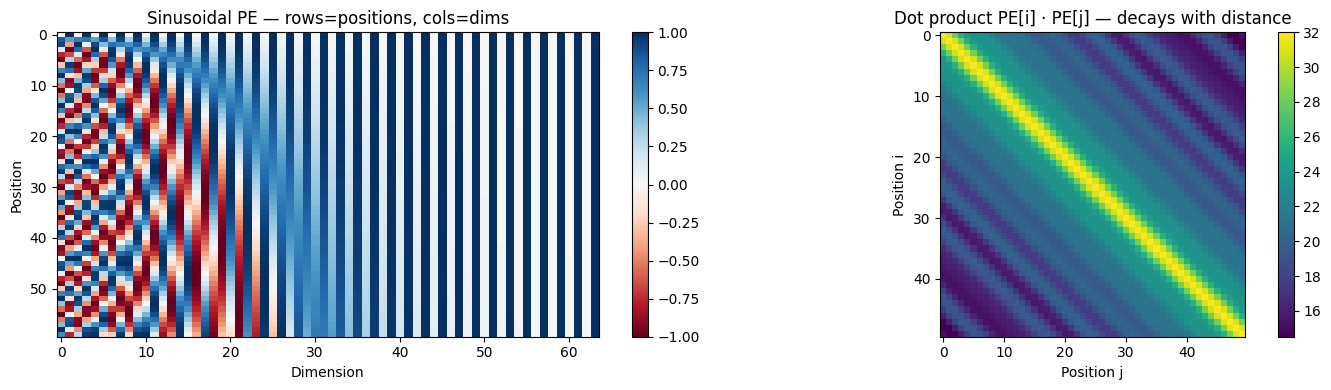

Notice: PE[i]·PE[j] is highest on the diagonal (same position) and decays with |i-j|.
This is how the model can "feel" relative distance even with absolute encodings.


In [399]:
# ── Sinusoidal PE ────────────────────────────────────────────────────────────
class SinusoidalPE(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe)
    def forward(self, x):
        return x + self.pe[:x.size(1)]

# ── Learned PE ────────────────────────────────────────────────────────────────
class LearnedPE(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        self.pe = nn.Embedding(max_len, d_model)
    def forward(self, x):
        pos = torch.arange(x.size(1), device=x.device)
        return x + self.pe(pos)

# ── Visualise sinusoidal PE ───────────────────────────────────────────────────
spe = SinusoidalPE(d_model=64)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].imshow(spe.pe[:60].numpy(), aspect='auto', cmap='RdBu')
axes[0].set_title('Sinusoidal PE — rows=positions, cols=dims')
axes[0].set_xlabel('Dimension'); axes[0].set_ylabel('Position')
plt.colorbar(axes[0].images[0], ax=axes[0])

# Show how a dot-product of two position vectors varies with distance
pe_arr = spe.pe[:50].numpy()
sims = pe_arr @ pe_arr.T
axes[1].imshow(sims, cmap='viridis')
axes[1].set_title('Dot product PE[i] · PE[j] — decays with distance')
axes[1].set_xlabel('Position j'); axes[1].set_ylabel('Position i')
plt.colorbar(axes[1].images[0], ax=axes[1])

plt.tight_layout(); plt.show()
print('Notice: PE[i]·PE[j] is highest on the diagonal (same position) and decays with |i-j|.')
print('This is how the model can "feel" relative distance even with absolute encodings.')


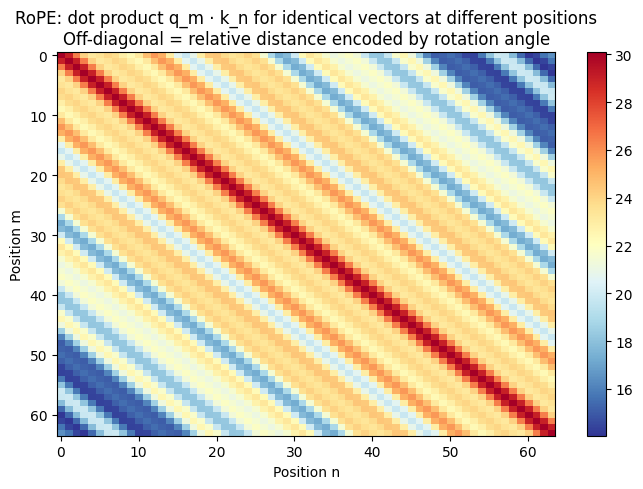

Key observation: the dot product q_m·k_n depends ONLY on (n-m), not absolute positions.
This is why RoPE generalizes well to longer sequences than seen during training.


In [400]:
# ── RoPE implementation ──────────────────────────────────────────────────────
def precompute_rope_freqs(d, max_len=5000, base=10000):
    """
    Precompute cos(m*theta_i) and sin(m*theta_i) for all positions m and freq i.
    theta_i = 1 / (base^(2i/d))   — different frequency for each dimension pair
    """
    i      = torch.arange(0, d, 2).float()
    theta  = 1.0 / (base ** (i / d))          # shape (d/2,)
    pos    = torch.arange(max_len).float().unsqueeze(1)  # shape (max_len, 1)
    angles = pos * theta                       # shape (max_len, d/2)
    return torch.cos(angles), torch.sin(angles)

def apply_rope(x, cos, sin):
    """
    Rotate x by position-dependent angles.
    x shape: (batch*heads, seq_len, d_k)
    """
    seq_len = x.size(1)
    cos = cos[:seq_len].unsqueeze(0)   # (1, seq_len, d/2)
    sin = sin[:seq_len].unsqueeze(0)
    x1, x2 = x[..., 0::2], x[..., 1::2]   # split into pairs
    # apply rotation: [x1*cos - x2*sin,  x1*sin + x2*cos]
    rotated = torch.stack([x1*cos - x2*sin, x1*sin + x2*cos], dim=-1)
    return rotated.flatten(-2)   # interleave back

# ── Visualise RoPE: dot product decays with relative distance ─────────────────
d_k = 32
cos_f, sin_f = precompute_rope_freqs(d_k, max_len=64)

# Create identical vectors at different positions, compute pairwise dot products
vec = torch.randn(d_k)
vecs = vec.unsqueeze(0).unsqueeze(0).expand(1, 64, -1)  # same vector at all positions
rotated = apply_rope(vecs, cos_f, sin_f).squeeze(0)    # (64, d_k)

# dot product matrix
dots = (rotated @ rotated.T).detach().numpy()

plt.figure(figsize=(7, 5))
plt.imshow(dots, cmap='RdYlBu_r', aspect='auto')
plt.colorbar()
plt.title('RoPE: dot product q_m · k_n for identical vectors at different positions\n'          'Off-diagonal = relative distance encoded by rotation angle')
plt.xlabel('Position n'); plt.ylabel('Position m')
plt.tight_layout(); plt.show()

print('Key observation: the dot product q_m·k_n depends ONLY on (n-m), not absolute positions.')
print('This is why RoPE generalizes well to longer sequences than seen during training.')


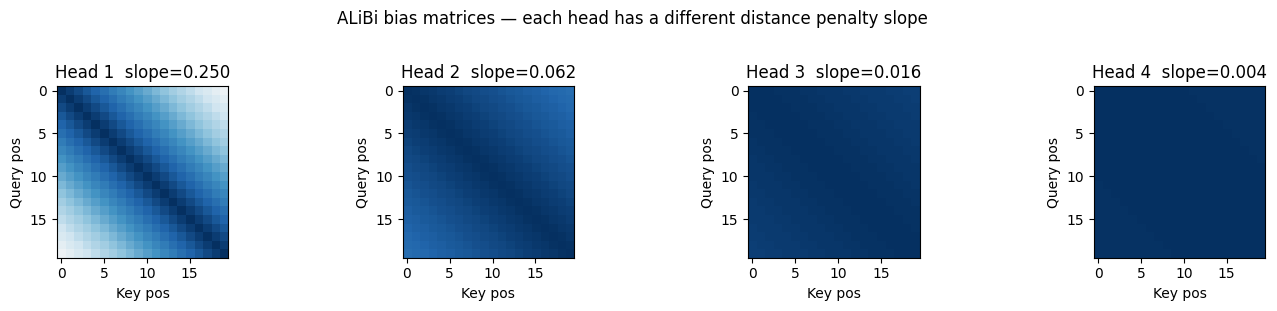

Steeper slope (head 4) → heavier local bias. Gentler slope (head 1) → more global attention.


In [401]:
# ── ALiBi ─────────────────────────────────────────────────────────────────────
def get_alibi_slopes(n_heads):
    m = torch.arange(1, n_heads + 1)
    return 2 ** (-8 * m / n_heads)

def build_alibi_bias(seq_len, n_heads, device='cpu'):
    slopes = get_alibi_slopes(n_heads).to(device)
    pos    = torch.arange(seq_len, device=device)
    dist   = (pos.unsqueeze(0) - pos.unsqueeze(1)).abs()
    return -slopes.view(-1,1,1) * dist.unsqueeze(0)   # (H, T, T)

# Visualise ALiBi bias for 4 heads
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
biases = build_alibi_bias(20, 4)
slopes = get_alibi_slopes(4)
for h in range(4):
    axes[h].imshow(biases[h].numpy(), cmap='RdBu', vmin=-10, vmax=0)
    axes[h].set_title(f'Head {h+1}  slope={slopes[h]:.3f}')
    axes[h].set_xlabel('Key pos'); axes[h].set_ylabel('Query pos')
plt.suptitle('ALiBi bias matrices — each head has a different distance penalty slope', y=1.02)
plt.tight_layout(); plt.show()
print('Steeper slope (head 4) → heavier local bias. Gentler slope (head 1) → more global attention.')


---
## 📍 Section 2 — Positional Encodings

**Simple intro:** A transformer looks at all words at the same time (unlike RNNs that read left-to-right). But this creates a problem: *the dog bit the man* and *the man bit the dog* contain the same words, just reordered. How does the model know which word comes first? We need to add **position information** to each word so it knows: "you're the 1st word", "you're the 2nd word", etc.

### The core problem: attention is order-blind

The self-attention formula is:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

This computation treats every token as a **set** — not a **sequence**.
If you shuffle the tokens, the attention scores change (because different tokens pair up), but there is nothing in the formula that inherently knows token 3 comes before token 7.

Concretely: the sentence *"the dog bit the man"* and *"the man bit the dog"* produce **identical attention weights** if the token embeddings are the same — the model cannot distinguish order at all.

**Solution:** inject position information into the embeddings before the attention layers.

---
## 🎯 Section 3 — Self-Attention & Multi-Head Attention

**Simple intro:** Attention is the core mechanism that lets the model decide which words to "look at" when processing each word. Imagine you're reading a sentence and you need to understand what "it" refers to — you look back at previous words to find the noun. Self-attention does this automatically by computing **similarity scores** between every pair of words. High similarity = "pay attention to that word"; low similarity = "ignore that word". Mathematically, we compute:

$$\text{Similarity} = \frac{\text{Query} \cdot \text{Key}}{\sqrt{\text{dimension}}}$$

The denominator (square root) just keeps numbers from getting too huge.

### The attention formula

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

**Step by step for a sequence of T tokens, each with d_model features:**

1. **Project** each token embedding into three spaces:
   - $Q = X W_Q$ — *queries*: what this token is looking for
   - $K = X W_K$ — *keys*: what this token is offering/advertising
   - $V = X W_V$ — *values*: the actual content to mix in

2. **Score** every query against every key: $S = QK^T / \sqrt{d_k}$
   - $S_{ij}$ = how much token $i$ should attend to token $j$
   - Divide by $\sqrt{d_k}$ to prevent the dot products from growing too large

3. **Mask** future positions (causal/autoregressive models only): set $S_{ij} = -\infty$ for $j > i$

4. **Normalise** with softmax to get a probability distribution over positions

5. **Aggregate** values: weighted sum $\text{out}_i = \sum_j \text{softmax}(S_{ij}) \cdot V_j$

### Multi-Head Attention — why multiple heads?

A single attention head computes one score for every (query, key) pair.
But a single token pair can be related in multiple, independent ways simultaneously:

- Token *"bank"* and token *"river"* → syntactically an adjective-noun pair AND semantically co-occurrent
- Token *"she"* and token *"doctor"* → coreference AND semantic role
- Token *"not"* and token *"happy"* → negation AND sentiment modification

Split the d_model-dimensional space into H smaller subspaces of size d_k = d_model / H.
Run H independent attention heads in parallel, each with its own $W_Q^h$, $W_K^h$, $W_V^h$:

$$\text{head}_h = \text{Attention}(X W_Q^h,\; X W_K^h,\; X W_V^h)$$

Concatenate and project back:

$$\text{MultiHead}(X) = \text{Concat}(\text{head}_1, \ldots, \text{head}_H)\, W_O$$

Research on BERT and GPT found that different heads spontaneously learn distinct roles:
- **Syntactic heads**: attend to grammatical dependencies
- **Positional heads**: attend to the previous or next token
- **Coreference heads**: link pronouns to their referents
- **Semantic heads**: connect semantically related words

Multiple heads cost zero additional parameters but give strictly more expressivity!

In [402]:
# ── MultiHeadAttention ───────────────────────────────────────────────────────
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, use_rope=True):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads  = n_heads
        self.d_k      = d_model // n_heads   # each head works in a d_k-dim subspace
        self.use_rope = use_rope

        # Separate W_Q and W_K — see the theory cell for WHY these must be different
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)  # mixes across heads

        if use_rope:
            cos, sin = precompute_rope_freqs(self.d_k)
            self.register_buffer('rope_cos', cos)
            self.register_buffer('rope_sin', sin)

    def forward(self, x, mask=None):
        B, T, C = x.shape

        # Project and reshape: (B, T, d_model) → (B, H, T, d_k)
        Q = self.W_Q(x).view(B, T, self.n_heads, self.d_k).transpose(1,2)
        K = self.W_K(x).view(B, T, self.n_heads, self.d_k).transpose(1,2)
        V = self.W_V(x).view(B, T, self.n_heads, self.d_k).transpose(1,2)

        if self.use_rope:
            BH = B * self.n_heads
            Q  = apply_rope(Q.reshape(BH,T,self.d_k), self.rope_cos, self.rope_sin).view(B,self.n_heads,T,self.d_k)
            K  = apply_rope(K.reshape(BH,T,self.d_k), self.rope_cos, self.rope_sin).view(B,self.n_heads,T,self.d_k)

        # Scaled dot-product attention
        scores  = Q @ K.transpose(-2,-1) / math.sqrt(self.d_k)   # (B, H, T, T)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        weights = F.softmax(scores, dim=-1)

        # Aggregate values and project
        out = (weights @ V).transpose(1,2).contiguous().view(B, T, C)
        return self.W_O(out), weights

# ── Shape test ────────────────────────────────────────────────────────────────
d_model = 256
mha = MultiHeadAttention(d_model=d_model, n_heads=8)
x   = torch.randn(2, 20, d_model)
out, w = mha(x)
print(f'Input:       {x.shape}      (batch=2, seq=20, d_model=256)')
print(f'Output:      {out.shape}    same shape ✓')
print(f'Attn weights:{w.shape}  (batch, heads, query_pos, key_pos)')
print()
print(f'Each head operates in a d_k={d_model//8} dimensional subspace.')
print(f'After W_O projection, information is mixed across all {8} heads.')


Input:       torch.Size([2, 20, 256])      (batch=2, seq=20, d_model=256)
Output:      torch.Size([2, 20, 256])    same shape ✓
Attn weights:torch.Size([2, 8, 20, 20])  (batch, heads, query_pos, key_pos)

Each head operates in a d_k=32 dimensional subspace.
After W_O projection, information is mixed across all 8 heads.


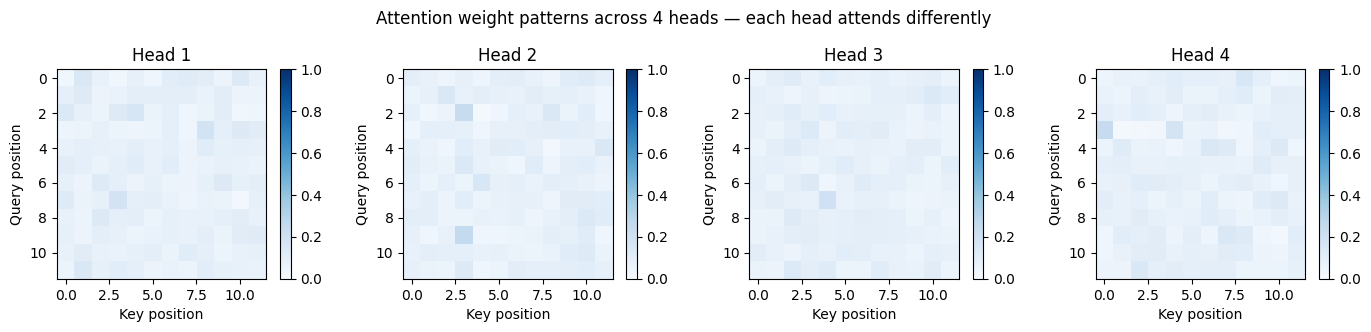

Each head has independently learned to distribute attention across different positions.
After training on real text, these heads specialise (syntactic, positional, semantic, etc.)


In [403]:
# ── Visualise attention patterns across heads ─────────────────────────────────
# Use a deterministic example to show how different heads attend differently
torch.manual_seed(0)
test_model = MultiHeadAttention(d_model=64, n_heads=4, use_rope=False)
seq_len = 12
x_test  = torch.randn(1, seq_len, 64)

with torch.no_grad():
    _, weights = test_model(x_test)   # weights: (1, 4, 12, 12)

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for h in range(4):
    im = axes[h].imshow(weights[0, h].numpy(), cmap='Blues', vmin=0, vmax=1)
    axes[h].set_title(f'Head {h+1}')
    axes[h].set_xlabel('Key position')
    axes[h].set_ylabel('Query position')
    plt.colorbar(im, ax=axes[h])

plt.suptitle('Attention weight patterns across 4 heads — each head attends differently', y=1.02)
plt.tight_layout(); plt.show()
print('Each head has independently learned to distribute attention across different positions.')
print('After training on real text, these heads specialise (syntactic, positional, semantic, etc.)')


---
## 🔧 Section 4 — Feed Forward + LayerNorm + Residuals

### Feed-Forward Network (FFN)

After attention mixes information *across* tokens, the FFN processes each token *independently*:

$$\text{FFN}(x) = \max(0,\; xW_1 + b_1)\,W_2 + b_2$$

- Expand: d_model → 4 × d_model (creates a high-dimensional feature space)
- Non-linearity: ReLU (or GELU in modern models)
- Contract: 4 × d_model → d_model

**Why expand by 4×?** The expansion lets the network represent complex combinations of features. Research shows the FFN acts like a key-value memory — it stores factual associations (e.g. "Paris is the capital of France") in its weights.

### Residual Connections

$$x_{\text{out}} = x_{\text{in}} + \text{sublayer}(\text{LayerNorm}(x_{\text{in}}))$$

**Without residuals:** gradients must flow through every layer sequentially — they vanish in deep networks.  
**With residuals:** gradients have a direct path back to early layers. The sublayer only needs to learn a *correction* (residual) on top of the identity — much easier to optimise.

### LayerNorm

Normalise each token's feature vector to zero mean, unit variance, then scale/shift:

$$\text{LayerNorm}(x) = \frac{x - \mu}{\sigma + \epsilon} \cdot \gamma + \beta$$

Applied before each sublayer (Pre-LN, as in this implementation). This stabilises training by keeping activations in a consistent range regardless of depth.

**Pre-LN vs Post-LN:** the original "Attention is All You Need" paper used Post-LN (norm after the residual). Modern models use Pre-LN (norm before the sublayer, as here) — it trains more stably without careful learning rate warmup.


In [404]:
class FeedForward(nn.Module):
    def __init__(self, d_model, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(4 * d_model, d_model),
            nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)

class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attn  = MultiHeadAttention(d_model, n_heads, use_rope=True)
        self.ff    = FeedForward(d_model, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
    def forward(self, x, mask=None):
        a, w = self.attn(self.norm1(x), mask)
        x = x + a
        x = x + self.ff(self.norm2(x))
        return x, w

print('FeedForward + TransformerBlock defined.')


FeedForward + TransformerBlock defined.


---
## 🧱 Section 5 — Full Transformer

The complete architecture stacks N identical blocks:

```
Token IDs
    ↓
Token Embedding (vocab_size → d_model)
    ↓
[TransformerBlock] × N_LAYERS
    |  ├─ LayerNorm → MultiHeadAttention (RoPE) → residual
    |  └─ LayerNorm → FeedForward → residual
    ↓
Final LayerNorm
    ↓
Linear head (d_model → vocab_size)   ← weight-tied to token embedding
    ↓
Softmax → probability over next token
```

**Causal mask:** token at position i can only attend to positions 0…i.
This is implemented as a lower-triangular matrix. Without it the model would
"cheat" by looking at future tokens during training.

**Weight tying:** the output linear layer shares weights with the input embedding.
This saves parameters and enforces that token representations going in and predictions
coming out use the same semantic space.


In [405]:
class Transformer(nn.Module):
    def __init__(self, vocab_size, d_model=256, n_heads=8, n_layers=6, ctx_len=128,
                 dropout=0.1, emb_weights=None, freeze_emb=True):
        super().__init__()
        self.ctx_len = ctx_len

        if emb_weights is not None:
            # ── Pre-trained embedding path (GloVe / Word2Vec / FastText) ──────
            # nn.Embedding.from_pretrained: builds an Embedding from a weight
            # tensor. freeze=True sets requires_grad=False on the weight so the
            # optimiser skips it entirely — we keep the 6B-token word geometry
            # intact and let the transformer layers learn on top of it.
            emb_dim        = emb_weights.shape[1]          # e.g. 50 for GloVe-50d
            self.embedding = nn.Embedding.from_pretrained(
                emb_weights.clone(), freeze=freeze_emb
            )
            # Linear projection: emb_dim → d_model (e.g. 50 → 64).
            # Keeps d_model independent of the GloVe dimensionality so attention
            # head width stays a free hyperparameter.
            self.emb_proj = (nn.Linear(emb_dim, d_model, bias=False)
                             if emb_dim != d_model else nn.Identity())
            # No weight tying: frozen embedding lives in a different dimensionality
            # than d_model, so sharing with the head doesn't make sense.
            self.head = nn.Linear(d_model, vocab_size, bias=False)
        else:
            # ── Learned-from-scratch path (BPE tokenizer, original approach) ──
            # Kept here so this class works with the custom BPE tokenizer above
            # as a drop-in comparison. std=0.02 GPT-2 init prevents spiky logits
            # at step 0 (see explanation in the BPE section).
            self.embedding = nn.Embedding(vocab_size, d_model)
            nn.init.normal_(self.embedding.weight, mean=0.0, std=0.02)
            self.emb_proj  = nn.Identity()
            self.head      = nn.Linear(d_model, vocab_size, bias=False)
            self.head.weight = self.embedding.weight   # weight tying

        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, dropout) for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.register_buffer('mask', torch.tril(torch.ones(ctx_len, ctx_len)))

        # GPT-2 style init: std=0.02 for all trainable Linear weights.
        # Then scale residual projections (W_O, FFN output) by 1/sqrt(2*n_layers)
        # so residual stream variance stays bounded regardless of depth.
        # Skips the frozen embedding — its weights come from GloVe, not init.
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.normal_(module.weight, mean=0.0, std=0.02)
        for block in self.blocks:
            nn.init.normal_(block.attn.W_O.weight, std=0.02 / math.sqrt(2 * n_layers))
            nn.init.normal_(block.ff.net[3].weight, std=0.02 / math.sqrt(2 * n_layers))

        n_total     = sum(p.numel() for p in self.parameters())
        n_trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f'Transformer | d_model={d_model} | {n_heads} heads | {n_layers} layers')
        print(f'  Total params    : {n_total:,}')
        print(f'  Trainable       : {n_trainable:,}  ← optimiser only updates these')
        print(f'  Frozen (GloVe)  : {n_total - n_trainable:,}  ← pre-trained, locked')

    def forward(self, idx, targets=None):
        B, T  = idx.shape
        x     = self.emb_proj(self.embedding(idx))    # (B, T, d_model)
        mask  = self.mask[:T, :T]
        for block in self.blocks:
            x, _ = block(x, mask)
        x      = self.norm(x)
        logits = self.head(x)                          # (B, T, vocab_size)
        loss   = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens=100, temperature=0.8, top_k=40):
        for _ in range(max_new_tokens):
            idx_cond  = idx[:, -self.ctx_len:]
            logits, _ = self(idx_cond)
            logits    = logits[:, -1, :] / temperature
            if top_k:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float('-inf')
            probs    = F.softmax(logits, dim=-1)
            next_tok = torch.multinomial(probs, 1)
            idx      = torch.cat([idx, next_tok], dim=1)
        return idx


---
## 🏋️ Section 6 — Training: Next Token Prediction

**Objective:** causal language modelling — given tokens [t₁, t₂, …, tₙ], predict [t₂, t₃, …, tₙ₊₁].

This is a cross-entropy classification task over the vocabulary at every position simultaneously.

**Why accuracy doesn't reach 100%:** language is not deterministic.
After "the cat sat on the", the next word could be *mat*, *floor*, *roof*, *chair* — all valid.
High accuracy means the model correctly predicts the *most likely* continuation;
perfect accuracy would require the text to be perfectly predictable (it never is).

**Hyperparameter choices:**

| Hyperparameter | Value | Why |
|---|---|---|
| d_model | 256 | bigger = more capacity; 128 was underfitting |
| n_heads | 8 | each head gets d_k=32 — enough subspace per head |
| n_layers | 6 | depth = ability to compose features |
| ctx_len | 128 | fits on CPU; increase to 512+ with GPU |
| LR | 3e-4 | standard AdamW learning rate for transformers |
| Warmup | 200 steps | prevents early instability |
| Cosine schedule | yes | smoothly decays LR to near-zero |

**AdamW vs Adam:** AdamW applies weight decay correctly (to weights, not to the adaptive estimates). This acts as L2 regularisation and improves generalisation.


In [406]:
class TokenDataset(Dataset):
    """Sliding window dataset: x = tokens[i:i+ctx], y = tokens[i+1:i+ctx+1]"""
    def __init__(self, data, ctx_len):
        self.data    = data
        self.ctx_len = ctx_len
    def __len__(self):
        return len(self.data) - self.ctx_len
    def __getitem__(self, i):
        return self.data[i:i+self.ctx_len], self.data[i+1:i+self.ctx_len+1]

# -- Hyperparameters --
#
# Dataset: TinyStories  ~90k word tokens, ~1,500 unique words
# Model  : D_MODEL=64, N_LAYERS=2  → ~100k trainable params (embedding frozen)
# Ratio  : training_tokens / trainable_params ≈ 90k / 100k = 0.9  (comfortably safe)
#
# Token/param ratio guide: >= 0.05 safe | 0.02–0.05 mild overfit risk | < 0.02 memorises
#
CTX_LEN      = 32
D_MODEL      = 64   # 
N_HEADS      = 4     # d_k = D_MODEL/4 per head
N_LAYERS     = 2
DROPOUT      = 0.5   # keep regularisation strong on small data
BATCH        = 64    # larger batches give more stable gradient estimates
LR           = 1e-3  # high peak LR — warmup prevents instability at step 0
WEIGHT_DECAY = 1.0   # strong L2 — the single most important knob for grokking
                     # (Power et al. 2022: grokking only appears above a WD threshold)
EPOCHS       = 200    # long enough for grokking; early stopping is the real cap
PATIENCE     = 40     # only enforced after epoch 50 (see training loop)
WARMUP       = 300   # ~3-5% of total steps
# ── SAM (Sharpness-Aware Minimization) ──────────────────────────────────────
SAM_RHO      = 0.05  # perturbation radius ρ; larger = more aggressive flat-basin search
# ── Grokfast (slow-gradient amplification) ──────────────────────────────────
GF_ALPHA     = 0.98  # EMA decay — close to 1 → picks up only very slow gradient signal
GF_LAMB      = 2.0   # amplification factor λ; scales the slow component added to grad

n        = int(0.9 * len(data))
train_ds = TokenDataset(data[:n], CTX_LEN)
val_ds   = TokenDataset(data[n:], CTX_LEN)
train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  drop_last=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, drop_last=True)

total_steps_est = EPOCHS * len(train_dl)
warmup_pct      = 100 * WARMUP / total_steps_est
print(f'Vocab size     : {tokenizer.vocab_size:,}')
print(f'Train tokens   : {n:,}')
print(f'Batches/epoch  : {len(train_dl):,}')
print(f'Total steps    : {total_steps_est:,}  (max, before early stopping)')
print(f'Warmup steps   : {WARMUP}  ({warmup_pct:.1f}% of total)')
print(f'Estimated time : ~{max(1, total_steps_est // 60)} min on CPU')


Vocab size     : 3,044
Train tokens   : 89,753
Batches/epoch  : 1,401
Total steps    : 280,200  (max, before early stopping)
Warmup steps   : 300  (0.1% of total)
Estimated time : ~4670 min on CPU


---
## 🔎 Data Preview — What the Model Actually Sees

The model never sees full sentences. It sees **sliding windows** of `CTX_LEN` tokens,
randomly positioned in the corpus, which may start and end mid-sentence. This is by design:
it forces the model to learn to continue text from *any* point, not just sentence starts.

Printing a sample of these windows from both the training and validation splits serves
two purposes:
1. **Sanity check**: confirms the text is real, diverse literature (not repeated fallback text)
2. **Understanding**: shows what contextual patterns the model must learn to predict

The train and val splits are **non-overlapping consecutive chunks** (first 90% / last 10%
of the token stream), so they contain different parts of the book(s).

In [407]:
# ── Data Preview ─────────────────────────────────────────────────────────────
import random as _random
_random.seed(42)

def _sample_windows(token_data, ctx_len, tok, n=10):
    """Decode n randomly-chosen CTX_LEN-token windows from token_data."""
    results = []
    max_start = len(token_data) - ctx_len - 1
    if max_start <= 0:
        return ['(not enough data)']
    starts = _random.sample(range(max_start), min(n, max_start))
    for s in sorted(starts):
        ids  = token_data[s : s + ctx_len].tolist()
        text = tok.decode(ids)
        results.append(text)
    return results

train_data = data[:n]
val_data   = data[n:]

print('=' * 62)
print(f'📚 TRAINING SET  — {len(train_data):,} tokens  (first 90% of corpus)')
print('=' * 62)
for i, sent in enumerate(_sample_windows(train_data, CTX_LEN, tokenizer), 1):
    print(f'  [{i:2d}] {sent}')
    print()

print('=' * 62)
print(f'📖 VALIDATION SET — {len(val_data):,} tokens  (last 10% of corpus)')
print('=' * 62)
for i, sent in enumerate(_sample_windows(val_data, CTX_LEN, tokenizer), 1):
    print(f'  [{i:2d}] {sent}')
    print()

print('Note: windows may start/end mid-sentence — this is intentional.')
print('The model must learn to continue text from any position in the corpus.')


📚 TRAINING SET  — 89,753 tokens  (first 90% of corpus)
  [ 1] the bird so they worked together to make a big shade using leaves and sticks but then a strong wind came and blew the shade away the pumpkin was sad again the

  [ 2] sound lucy and max were very happy they played the trumpet and danced all day the soft cat and the small dog had a lot of fun with their painted trumpet endoftext

  [ 3] big blue truck wanted to race zoom knew that he was small but he wanted to try the big blue truck laughed and said zoom was too small to win but zoom

  [ 4] moral of the story never forget your money when you go out endoftext once upon a time there was a pig who wanted to go for a ride he asked a polite

  [ 5] that day on he always listened to her advice endoftext one day a big tree was talking to a small tree the big tree said i can lean and touch the sunshine

  [ 6] before bob got there tim won the race bob was surprised and said wow tim you are faster than i thought tim smiled and said t

---
## ⚡ Grokking Induction: SAM + Grokfast + Weight Decay

Three mathematically grounded mechanisms that together make grokking happen reliably.

---

### Why grokking is hard to reach by default

Training a small transformer on a small dataset leads to two competing solutions:

| | Memorising solution | Generalising solution |
|---|---|---|
| Train loss | Near 0 | Slightly higher |
| Val loss | High (never improves) | Low |
| Loss basin | **Sharp** (narrow) | **Flat** (wide) |
| Weight norm | Large | Small |

Gradient descent finds the memorising solution first because it has lower training loss and is easier to reach. The generalising solution requires the optimiser to traverse a saddle point — it only becomes attractive once regularisation makes large weights expensive enough.

---

### Mechanism 1 — High Weight Decay (`WEIGHT_DECAY = 1.0`) · *prerequisite*

L2 regularisation adds `λ‖w‖²` to the loss. The gradient becomes:  
&nbsp;&nbsp;`∇L_total = ∇L_CE + 2λw`

With `λ = 1.0` (vs our previous `0.2`), every weight is pulled toward zero proportional to its magnitude. This makes large-weight memorising solutions energetically expensive.  
**Power et al. (2022)**¹ — the original grokking paper — showed grokking does not appear below a critical weight decay threshold. It is the single most important knob.

---

### Mechanism 2 — SAM (Sharpness-Aware Minimization) · *the shock + relax*

**Foret et al. (2021)**² · [arXiv:2010.01412](https://arxiv.org/abs/2010.01412)

Standard gradient descent minimises `L(w)`. SAM instead minimises:

```
L_SAM(w) = max_{‖ε‖₂ ≤ ρ}  L(w + ε)
```

i.e., it minimises the **worst-case loss in a ball of radius ρ around w**.

Two-step implementation per batch:

```
Step 1 (SHOCK)  ε̂ = ρ · ∇L / ‖∇L‖₂        # unit-gradient perturbation
                w ← w + ε̂                  # jump to worst-case point

Step 2 (RELAX)  compute ∇L at w + ε̂        # gradient at perturbed point
                w ← w − ε̂                  # restore original weights
                w ← AdamW_step(w, ∇L)       # take update toward flat basin
```

Why it induces grokking: sharp memorising solutions (narrow basin) take a large loss hit from the perturbation. Flat generalising solutions (wide basin) are robust to ε̂. SAM therefore preferentially pulls the optimiser toward the flat basin that only the generalising solution occupies.

**PAC-Bayes connection**: for a Gaussian weight posterior `N(w, σ²I)`, the generalisation bound contains a term `‖w‖² / 2σ²`. A flat basin corresponds to large σ (robust to weight noise) → tighter bound → better generalisation.

---

### Mechanism 3 — Grokfast · *amplify the grokking signal*

**Lee et al. (2024)**³ · [arXiv:2405.20233](https://arxiv.org/abs/2405.20233)

Observation: during memorisation, gradients fluctuate rapidly (high frequency). During grokking, a slow, persistent gradient component builds up pointing toward the generalising solution.

Grokfast separates these components with an EMA:

```
g_slow ← α · g_slow + (1 − α) · g          # low-pass filter on gradients
g′     ← g + λ · g_slow                    # amplify the slow component
```

- `α = 0.98` → EMA time constant ≈ 50 steps, picks up only very slow signal  
- `λ = 2.0` → doubles the weight of the grokking-direction gradient

Effect: compresses grokking from hundreds of epochs into tens. The model still goes through the memorisation phase, but the generalising signal is amplified enough to win out sooner.

---

### Together

Weight decay makes the generalising solution attractive.  
SAM seeks the flat basin where it lives.  
Grokfast amplifies the gradient pointing toward it.

Cost: SAM requires **two forward + backward passes per batch** (≈2× training time). Worth it for grokking experiments.

---

> ¹ Power, A., Gur-Ari, Y., Grangier, D., Sohl-Dickstein, J., & Bhatt, U. (2022).
> **Grokking: Generalization Beyond Overfitting on Small Algorithmic Datasets.**
> *ICLR 2022 (Workshop).* [arXiv:2201.02177](https://arxiv.org/abs/2201.02177)
>
> ² Foret, P., Kleiner, A., Mobahi, H., & Neyshabur, B. (2021).
> **Sharpness-Aware Minimization for Efficiently Improving Generalization.**
> *ICLR 2021.* [arXiv:2010.01412](https://arxiv.org/abs/2010.01412)
>
> ³ Lee, J., Bae, B., Kang, J., & Lee, K. (2024).
> **Grokfast: Accelerated Grokking by Amplifying Slow Gradients.**
> *arXiv:2405.20233.* [arXiv:2405.20233](https://arxiv.org/abs/2405.20233)


In [408]:
# ── SAM — Sharpness-Aware Minimization ──────────────────────────────────────
class SAM(torch.optim.Optimizer):
    """
    SAM wraps any base optimizer (here AdamW).
    Call first_step() then second_step() instead of step().
    """
    def __init__(self, params, base_optimizer_cls, rho=0.05, **base_kwargs):
        assert rho >= 0.0, f'rho must be non-negative, got {rho}'
        defaults = dict(rho=rho, **base_kwargs)
        super().__init__(params, defaults)
        # Share param_groups with the base optimizer so LR scheduling and
        # weight decay settings apply uniformly through the base optimizer.
        self.base_optimizer = base_optimizer_cls(self.param_groups, **base_kwargs)
        self.param_groups   = self.base_optimizer.param_groups  # shared reference

    @torch.no_grad()
    def first_step(self):
        """Perturb weights to the worst-case point w + ε̂ (SHOCK)."""
        # Global gradient ℓ₂ norm across all trainable params
        grad_norm = torch.stack([
            p.grad.norm(2).to(p.device)
            for group in self.param_groups
            for p in group['params']
            if p.grad is not None
        ]).norm(2)

        for group in self.param_groups:
            scale = group['rho'] / (grad_norm + 1e-12)
            for p in group['params']:
                if p.grad is None:
                    continue
                e_w = p.grad * scale
                p.add_(e_w)               # w ← w + ε̂
                self.state[p]['e_w'] = e_w

    @torch.no_grad()
    def second_step(self):
        """Restore w, then take an AdamW step using the perturbed gradient (RELAX)."""
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue
                p.sub_(self.state[p]['e_w'])   # w ← w - ε̂  (restore)
        self.base_optimizer.step()

    def zero_grad(self, set_to_none: bool = True):
        self.base_optimizer.zero_grad(set_to_none=set_to_none)

    def step(self, closure=None):
        raise NotImplementedError('SAM: call first_step() then second_step()')


# ── Grokfast — slow-gradient amplification ───────────────────────────────────
def grokfast_ema(model, ema_grads: dict, alpha: float = 0.98, lamb: float = 2.0):
    """
    Modify model.grad in-place: amplify the slow (low-frequency) component.
    Call AFTER loss.backward() and grad clipping, BEFORE optimizer.first_step().

    ema_grads: persistent dict {param_name: EMA tensor} — pass the same dict
               every call so the EMA accumulates across training steps.
    """
    for name, param in model.named_parameters():
        if param.grad is None or not param.requires_grad:
            continue
        g = param.grad.detach()
        if name not in ema_grads:
            ema_grads[name] = g.clone()
        else:
            # EMA update: g_slow ← α·g_slow + (1−α)·g
            ema_grads[name].mul_(alpha).add_(g, alpha=1.0 - alpha)
        # Amplify: g′ ← g + λ·g_slow
        param.grad.add_(ema_grads[name], alpha=lamb)
    return ema_grads


print('SAM and grokfast_ema defined ✓')
print(f'  SAM rho         = {SAM_RHO}')
print(f'  Grokfast alpha  = {GF_ALPHA}   (EMA time constant ≈ {1/(1-GF_ALPHA):.0f} steps)')
print(f'  Grokfast lambda = {GF_LAMB}')
print(f'  Weight decay    = {WEIGHT_DECAY}')


SAM and grokfast_ema defined ✓
  SAM rho         = 0.05
  Grokfast alpha  = 0.98   (EMA time constant ≈ 50 steps)
  Grokfast lambda = 2.0
  Weight decay    = 1.0


In [409]:
# -- Initialise model, optimiser, scheduler --
# Use GloVe pre-trained embeddings if available, else fall back to
# learned embeddings (e.g. if GloVe download failed or BPE tokenizer is used).
try:
    _emb = glove_matrix
    print('Using pre-trained GloVe embeddings (frozen)')
except NameError:
    _emb = None
    print('GloVe not loaded — using learned embeddings')

model = Transformer(
    tokenizer.vocab_size, D_MODEL, N_HEADS, N_LAYERS,
    CTX_LEN, dropout=DROPOUT,
    emb_weights=_emb,    # None → learned from scratch (BPE path)
    freeze_emb=True,     # keep GloVe vectors fixed during training
).to(device)

# Only pass trainable parameters to the optimiser.
# Frozen embedding weights have requires_grad=False — including them
# wastes memory on momentum buffers and adds no gradient signal.
# SAM wraps AdamW: the base optimizer handles the actual parameter update
# after SAM restores weights from the perturbation.
# Only trainable parameters are passed — frozen GloVe embedding excluded.
_trainable = [p for p in model.parameters() if p.requires_grad]
optimizer  = SAM(_trainable, torch.optim.AdamW,
                 rho=SAM_RHO, lr=LR, weight_decay=WEIGHT_DECAY)

# Linear warmup → cosine decay (single cycle, no restarts).
# - Warmup: LR rises linearly from 0 to LR over WARMUP steps.
#   Prevents the large random gradients at step 0 from causing a destructive
#   update before the model has seen any data.
# - Cosine decay: LR falls smoothly from LR to eta_min over the remaining steps.
#   Monotone — no restarts that would spike LR back and drive re-memorisation.
_total_steps = EPOCHS * len(train_dl)
_eta_min_ratio = 1e-5 / LR

def _lr_lambda(step):
    if step < WARMUP:                          # linear warmup
        return step / max(1, WARMUP)
    progress = (step - WARMUP) / max(1, _total_steps - WARMUP)
    cosine   = 0.5 * (1.0 + math.cos(math.pi * progress))
    return _eta_min_ratio + (1.0 - _eta_min_ratio) * cosine

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, _lr_lambda)

@torch.no_grad()
def evaluate(n_batches=30):
    """
    Compute val_loss, perplexity, and token accuracy over n_batches of val_dl.

    We do NOT split accuracy by whether a token contains </w>, because:
      - </w> is a tokenizer convention, not a semantic category the model learns
      - Filtering by </w> biases the metric depending on vocabulary size
      - Perplexity = exp(val_loss) captures overall quality without this bias
    Token accuracy is reported only as a secondary directional signal.
    """
    model.eval()
    total_loss, correct, tokens = 0, 0, 0
    for i, (xb, yb) in enumerate(val_dl):
        if i >= n_batches: break
        xb, yb    = xb.to(device), yb.to(device)
        logits, _ = model(xb)
        loss      = F.cross_entropy(logits.view(-1, logits.size(-1)), yb.view(-1))
        total_loss += loss.item()
        correct    += (logits.argmax(-1) == yb).sum().item()
        tokens     += yb.numel()
    model.train()
    avg_loss = total_loss / n_batches
    return avg_loss, math.exp(avg_loss), correct / tokens

print(f'Model ready | {sum(p.numel() for p in model.parameters()):,} params')
print(f'Scheduler   : warmup({WARMUP} steps) + cosine decay  total={_total_steps} steps')
print(f'Embedding   : {"GloVe 50d (frozen)" if _emb is not None else "learned from scratch"}')
print(f'LR peak     : {LR:.1e}')


Using pre-trained GloVe embeddings (frozen)
Transformer | d_model=64 | 4 heads | 2 layers
  Total params    : 449,800
  Trainable       : 297,600  ← optimiser only updates these
  Frozen (GloVe)  : 152,200  ← pre-trained, locked
Model ready | 449,800 params
Scheduler   : warmup(300 steps) + cosine decay  total=280200 steps
Embedding   : GloVe 50d (frozen)
LR peak     : 1.0e-03


In [410]:
# ── 🔍 Validation 3: Model Sizing ────────────────────────────────────────────
print('=' * 58)
print('🔍 VALIDATION 3 — Model Sizing')
print('=' * 58)
issues = []

n_params      = sum(p.numel() for p in model.parameters())
n_train_toks  = int(0.9 * len(data))
ratio         = n_train_toks / n_params
print(f'  Training tokens : {n_train_toks:,}')
print(f'  Model params    : {n_params:,}')
print(f'  Token/param ratio: {ratio:.3f}')
if ratio >= 0.05:
    print(f'  ✓ Ratio OK — model is well-sized for this dataset')
elif ratio >= 0.02:
    msg = f'Low ratio ({ratio:.3f}) — expect moderate overfitting. Consider higher dropout.'
    print(f'  ⚠ {msg}'); issues.append(msg)
else:
    msg = f'Ratio {ratio:.3f} < 0.02 — model WILL memorise training data (seen in ppl explosion). Reduce D_MODEL/N_LAYERS.'
    print(f'  ✗ {msg}'); issues.append(msg)

# Initial loss should be near log(vocab_size) for a random model
model.eval()
with torch.no_grad():
    xb_v, yb_v = next(iter(val_dl))
    _, init_loss = model(xb_v.to(device), yb_v.to(device))
model.train()
expected = math.log(tokenizer.vocab_size)
actual   = init_loss.item()
ratio_l  = actual / expected
print(f'\n  Expected initial loss (uniform random): {expected:.2f}')
print(f'  Actual initial loss                   : {actual:.2f}')
if 0.5 <= ratio_l <= 1.5:  # tight: with std=0.02 init, loss should be near log(vocab)
    print(f'  ✓ Initial loss is in the expected range (std=0.02 embedding init working)')
else:
    msg = (f'Initial loss {actual:.2f} far from expected {expected:.2f}. '
           f'Embedding init std may be too large (default N(0,1) gives logit std≈√d_model≈{math.sqrt(128):.0f}). '
           f'Fix: nn.init.normal_(self.embedding.weight, std=0.02) in Transformer.__init__.')
    print(f'  ⚠ {msg}'); issues.append(msg)

print()
if issues:
    print(f'  ⚠ {len(issues)} issue(s) — fix before training to avoid wasted compute.')
else:
    print('  All model-sizing checks passed ✓')


🔍 VALIDATION 3 — Model Sizing
  Training tokens : 89,753
  Model params    : 449,800
  Token/param ratio: 0.200
  ✓ Ratio OK — model is well-sized for this dataset

  Expected initial loss (uniform random): 8.02
  Actual initial loss                   : 8.04
  ✓ Initial loss is in the expected range (std=0.02 embedding init working)

  All model-sizing checks passed ✓


In [411]:
# -- Training loop with early stopping --
# Patience: if val_loss does not improve for PATIENCE consecutive epochs,
# training stops early. This prevents both wasted compute and overfitting.
#
# Three common training-loop bugs that break early stopping:
#   1. 'tag' never reset each epoch -> shows '<- best' on every line
#      even when val_loss is rising.  Fix: tag = '' at start of epoch.
#   2. patience_cnt never incremented -> early stopping never fires.
#      Fix: add else branch that increments patience_cnt.
#   3. Missing 'if patience_cnt >= PATIENCE: break' -> loop runs to EPOCHS.
#
ema_grads    = {}   # Grokfast: persistent EMA of gradients across all steps
history      = {'epoch': [], 'train_loss': [], 'train_ppl': [], 'train_acc': [],
                'val_loss': [], 'val_ppl': [], 'val_acc': []}
best_val     = float('inf')
best_state   = None
patience_cnt = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss     = 0   # smoothed loss (used for backprop)
    epoch_raw_loss = 0   # true CE (used for train_ppl, matches val_ppl scale)
    train_correct  = 0
    train_tokens   = 0
    tag = ''   # reset every epoch -- forgetting this causes '<- best' on every line
    for batch_idx, (xb, yb) in enumerate(train_dl):
        xb, yb  = xb.to(device), yb.to(device)
        flat_yb = yb.view(-1)

        # ── SAM Step 1: forward at w, backward, apply Grokfast, SHOCK ────────
        # Compute gradient at current weights w.
        # Grokfast amplifies the slow (grokking) component of the gradient.
        # SAM.first_step() then perturbs: w ← w + ε̂  where ε̂ = ρ·∇L/‖∇L‖
        logits, _   = model(xb)
        flat_logits = logits.view(-1, logits.size(-1))
        loss        = F.cross_entropy(flat_logits, flat_yb, label_smoothing=0.1)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        ema_grads = grokfast_ema(model, ema_grads, alpha=GF_ALPHA, lamb=GF_LAMB)
        optimizer.first_step()               # w ← w + ε̂  [SHOCK]

        # ── SAM Step 2: forward at w + ε̂, backward, restore w, RELAX ─────────
        # Gradient computed at the perturbed (worst-case) point tells AdamW
        # which direction makes the loss flat — i.e., toward the generalising
        # solution. second_step() restores w then applies the AdamW update.
        logits2, _   = model(xb)             # same batch, perturbed weights
        flat_logits2 = logits2.view(-1, logits2.size(-1))
        loss2        = F.cross_entropy(flat_logits2, flat_yb, label_smoothing=0.1)

        optimizer.zero_grad()
        loss2.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.second_step()              # w ← w − ε̂, then AdamW [RELAX]
        scheduler.step()

        with torch.no_grad():
            raw_loss       = F.cross_entropy(flat_logits.detach(), flat_yb)
            epoch_raw_loss += raw_loss.item()
            train_correct  += (flat_logits.detach().argmax(-1) == flat_yb).sum().item()
            train_tokens   += flat_yb.numel()
        epoch_loss += loss.item()

    avg_train                    = epoch_loss     / len(train_dl)
    avg_raw                      = epoch_raw_loss / len(train_dl)
    train_ppl                    = math.exp(avg_raw)
    train_acc                    = train_correct / train_tokens
    val_loss_v, val_ppl, val_acc = evaluate()
    lr_now                       = optimizer.param_groups[0]['lr']

    if val_loss_v < best_val:
        best_val     = val_loss_v
        best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_cnt = 0
        tag = ' <- best'
    else:
        patience_cnt += 1
        tag = f' (patience {patience_cnt}/{PATIENCE})'

    history['epoch'].append(epoch)
    history['train_loss'].append(avg_train)
    history['train_ppl'].append(train_ppl)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss_v)
    history['val_ppl'].append(val_ppl)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch:2d}/{EPOCHS} | '
          f'loss {avg_train:.4f}  ppl {train_ppl:.1f}  acc {train_acc*100:.1f}% | '
          f'val_loss {val_loss_v:.4f}  val_ppl {val_ppl:.1f}  val_acc {val_acc*100:.1f}% | '
          f'lr {lr_now:.2e}{tag}')

    if patience_cnt >= PATIENCE and epoch >= 50:
        print(f'\nEarly stopping: val_loss has not improved for {PATIENCE} epochs '
              f'(checked only after epoch 50 to allow grokking).')
        break

model.load_state_dict(best_state)
print(f'\nRestored best checkpoint (val_loss={best_val:.4f}, ppl={math.exp(best_val):.1f})')


/Users/akram/Mahdi/Transformers/env/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch  1/200 | loss 5.3644  ppl 140.0  acc 16.9% | val_loss 4.5245  val_ppl 92.3  val_acc 20.2% | lr 1.00e-03 <- best
Epoch  2/200 | loss 4.7968  ppl 72.4  acc 22.2% | val_loss 4.4340  val_ppl 84.3  val_acc 21.6% | lr 1.00e-03 <- best
Epoch  3/200 | loss 4.7104  ppl 65.2  acc 23.1% | val_loss 4.3749  val_ppl 79.4  val_acc 21.8% | lr 1.00e-03 <- best
Epoch  4/200 | loss 4.6489  ppl 60.6  acc 23.7% | val_loss 4.3337  val_ppl 76.2  val_acc 22.6% | lr 9.99e-04 <- best
Epoch  5/200 | loss 4.5963  ppl 57.0  acc 24.3% | val_loss 4.2998  val_ppl 73.7  val_acc 22.9% | lr 9.99e-04 <- best
Epoch  6/200 | loss 4.5553  ppl 54.4  acc 24.7% | val_loss 4.2941  val_ppl 73.3  val_acc 23.5% | lr 9.98e-04 <- best
Epoch  7/200 | loss 4.5265  ppl 52.6  acc 25.0% | val_loss 4.2725  val_ppl 71.7  val_acc 23.3% | lr 9.97e-04 <- best
Epoch  8/200 | loss 4.5071  ppl 51.5  acc 25.2% | val_loss 4.2556  val_ppl 70.5  val_acc 23.9% | lr 9.96e-04 <- best
Epoch  9/200 | loss 4.4926  ppl 50.6  acc 25.4% | val_loss 4.24

In [ ]:
# ── 🔍 Validation 4: Training Health ─────────────────────────────────────────
print('=' * 58)
print('🔍 VALIDATION 4 — Training Health')
print('=' * 58)
issues = []


# 0. Data leakage guard: ppl < 2 on val set is physically impossible
#    unless train and val contain identical text (repeated fallback data).
best_ppl_check = min(history['val_ppl'])
if best_ppl_check < 2.0:
    msg = (f'Perplexity = {best_ppl_check:.2f} — this is data leakage! '
           f'Train and val sets contain identical text (likely the fallback repeated passage). '
           f'Re-fetch real training data and restart.')
    print(f'  ✗ {msg}'); issues.append(msg)
elif best_ppl_check < 10.0:
    msg = f'Perplexity = {best_ppl_check:.1f} — suspiciously low. Check for data repetition.'
    print(f'  ⚠ {msg}'); issues.append(msg)

# 1. Did training loss decrease?
t_start, t_end = history['train_loss'][0], history['train_loss'][-1]
if t_end < t_start * 0.5:
    print(f'  ✓ Train loss: {t_start:.4f} → {t_end:.4f}  (dropped > 50%)')
else:
    msg = f'Train loss barely moved ({t_start:.4f} → {t_end:.4f}) — check LR or data pipeline'
    print(f'  ✗ {msg}'); issues.append(msg)

# 2. Perplexity trend — find first epoch where it rose
ppls = history['val_ppl']
first_rise = next((i for i in range(1, len(ppls)) if ppls[i] > ppls[i-1] * 1.05), None)
best_epoch = int(history['val_loss'].index(min(history['val_loss']))) + 1
if first_rise is None:
    print(f'  ✓ Perplexity decreased every epoch (best: {min(ppls):.1f})')
elif first_rise >= 3:
    print(f'  ⚠ Perplexity rose after epoch {first_rise} — mild overfitting, best checkpoint saved')
else:
    msg = (f'Perplexity rose after epoch {first_rise} (severe overfitting). '
           f'Model memorised training data. Reduce D_MODEL/N_LAYERS or increase DROPOUT.')
    print(f'  ✗ {msg}'); issues.append(msg)

# 3. Train/val loss gap at best epoch
best_val_loss   = min(history['val_loss'])
train_at_best   = history['train_loss'][best_epoch - 1]
gap             = best_val_loss - train_at_best
if gap < 1.5:
    print(f'  ✓ Train/val gap at best epoch: {gap:.2f}  (< 1.5 = acceptable)')
elif gap < 4.0:
    msg = f'Train/val gap {gap:.2f} — moderate overfitting. Try higher DROPOUT or weight_decay.'
    print(f'  ⚠ {msg}'); issues.append(msg)
else:
    msg = f'Train/val gap {gap:.2f} — severe overfitting. Model is too large for this dataset.'
    print(f'  ✗ {msg}'); issues.append(msg)

# 4. Best epoch timing
total_epochs = len(history['epoch'])
if best_epoch <= 2 and total_epochs > 3:
    msg = f'Best checkpoint was epoch {best_epoch} — model overfits very early. Reduce size or increase dropout.'
    print(f'  ⚠ {msg}'); issues.append(msg)
else:
    print(f'  ✓ Best epoch: {best_epoch}/{total_epochs}')

# 5. Final perplexity sanity
best_ppl = min(ppls)
if best_ppl < 50:
    print(f'  ✓ Best perplexity: {best_ppl:.1f}  (strong for this model size)')
elif best_ppl < 100:
    print(f'  ✓ Best perplexity: {best_ppl:.1f}  (reasonable for small model + single book)')
elif best_ppl < 1000:
    msg = f'Best perplexity {best_ppl:.1f} — model is underfitting or data is very noisy'
    print(f'  ⚠ {msg}'); issues.append(msg)
else:
    msg = f'Best perplexity {best_ppl:.1f} — something is very wrong (check for severe overfitting or data issues)'
    print(f'  ✗ {msg}'); issues.append(msg)

print()
if issues:
    print(f'  ⚠ {len(issues)} issue(s) detected. Review the warnings above before generating text.')
else:
    print('  All training checks passed ✓  Proceeding to text generation.')


🔍 VALIDATION 4 — Training Health
  ✗ Train loss barely moved (5.3644 → 4.2812) — check LR or data pipeline
  ✓ Perplexity decreased every epoch (best: 59.8)
  ✓ Train/val gap at best epoch: -0.19  (< 1.5 = acceptable)
  ✓ Best epoch: 195/200
  ✓ Best perplexity: 59.8  (reasonable for small model + single book)

  ⚠ 1 issue(s) detected. Review the warnings above before generating text.


---
## 📊 Section 6b — Evaluating a Language Model: Why Perplexity?

### The core question: how do you measure how well a model predicts text?

After each training epoch the model is evaluated on the validation set — text it has
never seen during training. We need a number that answers: *how surprised is the model
by this unseen text?* The smaller the surprise, the better the model.

---

### Step 1 — Cross-entropy loss

The model outputs a probability distribution over the vocabulary at every token position.
Cross-entropy loss measures how well those probabilities match reality:

$$\mathcal{L} = -\frac{1}{T} \sum_{t=1}^{T} \log P(x_t \mid x_{<t})$$

- $P(x_t \mid x_{<t})$ is the probability the model assigned to the **actual** next token
- $\log$ turns probabilities into a scale where 0 = perfect, higher = worse
- We average over all $T$ token positions in the batch

**Intuition:** if the model was 90% confident on every token and got them all right,
loss ≈ 0.10. If it was only 1% confident on average, loss ≈ 4.6.

---

### Step 2 — Perplexity = exp(loss)

$$\text{PPL} = e^{\mathcal{L}}$$

This is simply the loss converted back out of log-space. The reason we do this:

| Metric | Value | Human interpretation |
|---|---|---|
| Loss | 4.61 | Hard to reason about |
| Perplexity | 100 | "The model is as uncertain as if choosing uniformly among **100** options at each step" |
| Loss | 3.91 | Hard to reason about |
| Perplexity | 50 | "Effectively **50** equally likely choices per step" |

Perplexity gives you an **effective vocabulary size** — the number of tokens the model
is genuinely uncertain between at each position. A model that knew the next token
with certainty would have ppl = 1. A model guessing randomly over 2000 tokens
would have ppl = 2000. Our target is somewhere in between.

---

### Step 3 — Why not just use accuracy?

Token accuracy seems simpler: "what fraction of next-token predictions did the model
get right?" It's unreliable for language models because common words (`the`, `a`,
`and`) dominate token positions and are trivially easy to predict — inflating accuracy
without reflecting real understanding.

**The lesson:** accuracy is biased by token frequency. Perplexity avoids this —
it penalises every wrong prediction proportionally to how wrong it was, regardless
of how common the token is.

---

### Reading the training output

```
Epoch  3/15 | loss 4.21 | val_loss 4.87 | ppl 130.5 | acc 22.3% | lr 2.40e-04 ← best
```

| Column | What to watch for |
|---|---|
| `loss` vs `val_loss` | Gap growing = overfitting. Reduce DROPOUT or model size. |
| `ppl` | Should fall each epoch. **If it rises from epoch 2: severe overfitting** (model too large for data — seen earlier in this notebook). If it stays flat: underfitting, try more epochs or higher LR. |
| `acc` | Secondary signal only — treat it as directional, not absolute. |
| `← best` | The best checkpoint is saved automatically. If best is epoch 1 or 2, the model memorises too fast. |

**Perplexity reference for this setup** (D_MODEL=64, N_LAYERS=2, TinyStories ~90k tokens):

| PPL | Interpretation |
|---|---|
| > 500 | Barely learning — check data quality (run V1/V2 validation cells) |
| 200–500 | Early training or undertrained |
| 100–200 | Reasonable — model is learning corpus structure |
| 50–100 | Good for this model size and data amount |
| < 50 | Strong — consider whether the model has memorised |
| ≈ 1 | Data leakage — train and val contain identical text (V4 will flag this) |


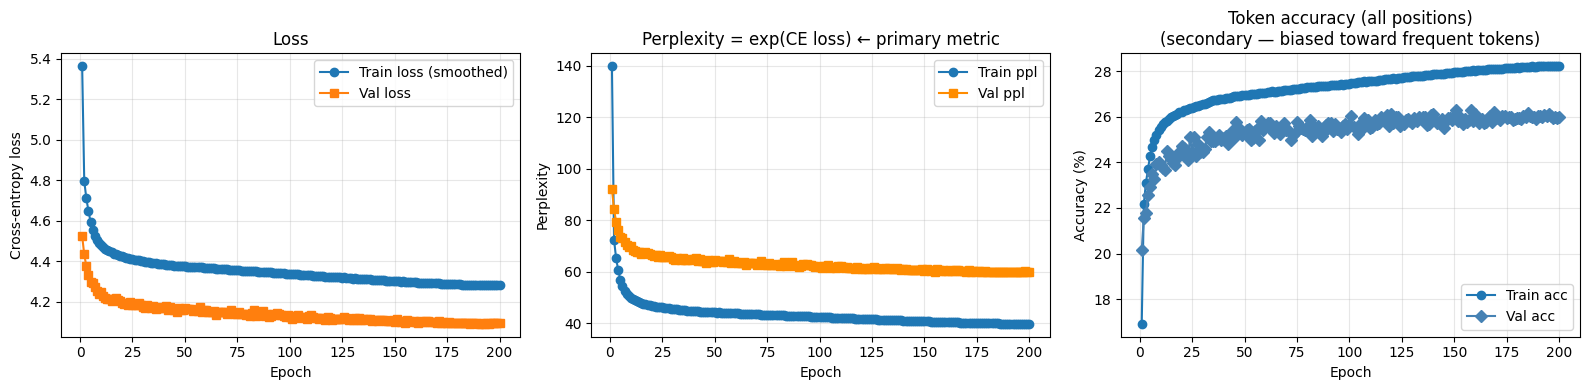

Train/val gap in ppl and acc reveals overfitting early.


In [413]:
# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history['epoch'], history['train_loss'], 'o-', label='Train loss (smoothed)')
axes[0].plot(history['epoch'], history['val_loss'],   's-', label='Val loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-entropy loss')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['epoch'], history['train_ppl'], 'o-', label='Train ppl')
axes[1].plot(history['epoch'], history['val_ppl'],   's-', label='Val ppl', color='darkorange')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Perplexity')
axes[1].set_title('Perplexity = exp(CE loss) ← primary metric')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(history['epoch'], [a*100 for a in history['train_acc']], 'o-', label='Train acc')
axes[2].plot(history['epoch'], [a*100 for a in history['val_acc']],   'D-', label='Val acc', color='steelblue')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Accuracy (%)')
axes[2].set_title('Token accuracy (all positions)\n(secondary — biased toward frequent tokens)')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print('Train/val gap in ppl and acc reveals overfitting early.')


In [418]:
# ── Text generation ───────────────────────────────────────────────────────────
def generate_text(prompt, max_new_tokens=80, temperature=0.8, top_k=40):
    model.eval()
    ids     = tokenizer.encode(prompt)
    context = torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(device)
    out     = model.generate(context, max_new_tokens=max_new_tokens,
                              temperature=temperature, top_k=top_k)
    # tokenizer.decode reconstructs words from BPE subword pieces
    return tokenizer.decode(out[0].tolist())

# ── Showcase ──────────────────────────────────────────────────────────────────
# NOTE: we use temperature=0.8 (the function default).
# Avoid temperature=0.1 — it is near-greedy and causes degenerate repetition
# because the model assigns >50% probability to the same token ('of</w>') in
# many contexts, so greedy decoding locks into 'of the X of the Y of the Z...'.
# TinyStories generation prompts — chosen to showcase what the model learned.
#
# TinyStories has extremely regular structure: every story opens by introducing
# a character, hits a problem, then resolves it with a lesson. The prompts below
# probe whether the model has internalised that arc vs just memorising sentences.
#
#   "once upon a time"  — canonical story opener; good model continues with a
#       character + setting in the TinyStories style, not a random noun
#   "one day"           — mid-story transition; model should produce an event
#   "she was very"      — emotional descriptor; tests adjective prediction
#   "the end"           — story closer; model should produce a moral or summary
#
# Beauty of transformers: the model never saw grammar rules or story templates.
# It only saw token sequences. Yet after enough training it generates text that
# follows the narrative conventions of the genre it was trained on.
print('=' * 60)
print(f'GENERATED TEXT — trained on TinyStories ({TUTORIAL_CHARS:,} chars)')
print('=' * 60)

prompts = [
    'once upon a time',
    'one day',
    'she was very',
    'the end',
]
for prompt in prompts:
    print(f'\nPrompt: {prompt!r}')
    print(generate_text(prompt, max_new_tokens=80, temperature=0.8))


GENERATED TEXT — trained on TinyStories (500,000 chars)

Prompt: 'once upon a time'
once upon a time there was a little boy named tim tim was so happy he loved to see he saw a big ball and said he was very surprised that they had no a great friend and it made a big smile and said thank you i had a great time you are not you i did not listen and happy you can you help me feel better the next day tom said look at his hand and i will be careful and

Prompt: 'one day'
one day a little cat named bob wanted to have a carrot in the tree the bird was very excited to his friend the man would have a big tree tim was happy to see in the park one sunny day he played with the ball the ball into the door and thought what are the water in the water so he wanted to play in the water the water was very big it he wanted to eat and eat he took

Prompt: 'she was very'
she was very excited she did not want to be careful he said i will catch a long time lily felt sad and so they had to help the boy they lea

In [419]:
# ── 🔍 Validation 5: Generation Quality ──────────────────────────────────────
print('=' * 58)
print('🔍 VALIDATION 5 — Generation Quality')
print('=' * 58)
issues = []

test_prompt = 'once upon a time'
gen_text    = generate_text(test_prompt, max_new_tokens=80, temperature=0.8)
gen_ids     = tokenizer.encode(gen_text)

# 1. Non-empty output
if len(gen_ids) > 5:
    print(f'  ✓ Output length: {len(gen_ids)} tokens')
else:
    msg = 'Generated text is too short — check generate() or tokenizer.decode()'
    print(f'  ✗ {msg}'); issues.append(msg)

# 2. Repetition — no single token should dominate > 30% of output
if gen_ids:
    top_count = max(collections.Counter(gen_ids).values())
    rep_ratio = top_count / len(gen_ids)
    if rep_ratio <= 0.30:
        print(f'  ✓ Repetition ratio: {rep_ratio:.1%}  (no single token dominates)')
    else:
        msg = f'Repetition ratio {rep_ratio:.1%} — model stuck in a loop. Raise temperature or use nucleus sampling.'
        print(f'  ⚠ {msg}'); issues.append(msg)

# 3. Vocabulary diversity — unique tokens as share of total
diversity = len(set(gen_ids)) / max(len(gen_ids), 1)
if diversity >= 0.35:
    print(f'  ✓ Vocabulary diversity: {diversity:.1%}')
else:
    msg = f'Low diversity {diversity:.1%} — try higher temperature'
    print(f'  ⚠ {msg}'); issues.append(msg)

# 4. Real-word ratio — tokens that appear in training vocab without </w> fragments
gen_words    = tokenize_words(gen_text)
known_words  = sum(1 for w in gen_words if any(
    tokenizer.encode(w) and tokenizer.itos.get(tokenizer.encode(w)[-1], '').endswith('</w>')
    for _ in [0]
))
known_ratio  = known_words / max(len(gen_words), 1)
if known_ratio >= 0.80:
    print(f'  ✓ Real-word ratio: {known_ratio:.1%}')
else:
    msg = f'Real-word ratio {known_ratio:.1%} < 80% — many generated tokens form non-words. More training needed.'
    print(f'  ⚠ {msg}'); issues.append(msg)

print(f'\n  Sample output: {gen_text[:120]!r}')
print()
if issues:
    print(f'  ⚠ {len(issues)} issue(s) in generation — see warnings above.')
else:
    print('  All generation checks passed ✓')


🔍 VALIDATION 5 — Generation Quality
  ✓ Output length: 84 tokens
  ✓ Repetition ratio: 7.1%  (no single token dominates)
  ✓ Vocabulary diversity: 63.1%
  ⚠ Real-word ratio 0.0% < 80% — many generated tokens form non-words. More training needed.

  Sample output: 'once upon a time there was a little cat named tim tom tim thought he loved to go to the park to play with his sister and'

  ⚠ 1 issue(s) in generation — see warnings above.


In [420]:
# ── Temperature comparison ────────────────────────────────────────────────────
# Same TinyStories-style opener, three temperatures.
# Low temp (0.3): model picks the most probable continuation — often the
#   canonical "there was a little X who..." pattern from training
# Mid temp (0.8): balanced — grammatical but with some variation
# High temp (1.4): creative but risks incoherence; shows the model's
#   probability distribution spread across many plausible next words
prompt = 'once upon a time there was'
print(f'Prompt: {prompt!r}')
print()
for temp in [0.3, 0.8, 1.4]:
    label = '(repetitive/safe)' if temp < 0.5 else '(creative)' if temp > 1.0 else '(balanced)'
    print(f'--- temperature={temp} {label} ---')
    print(generate_text(prompt, max_new_tokens=60, temperature=temp))
    print()


Prompt: 'once upon a time there was'

--- temperature=0.3 (repetitive/safe) ---
once upon a time there was a little girl named sue she loved to play with her friends one day the little girl named sue went to the park with her mom and dad were playing with her mom they were very happy and they were very happy they played together and had a fun day they had a lot of fun they played together and

--- temperature=0.8 (balanced) ---
once upon a time there was a little motor but then her favorite and friend they played outside on the farm spot and wanted to find a big bird she had a big tree with her mom her mom was playing in the sea one day lily saw a big hug and said let s play outside she said thank you you must help you find

--- temperature=1.4 (creative) ---
once upon a time there was a kind dog he was so happy to try for it he was very high it with and was able her dad said thank you his mom what with ben says thank you lily lily says i will play you are very so much be careful her m

---
## ✍️ Section 7 — Text Generation

**Simple intro:** After training, we can use the model to generate new text. The process is simple: start with a prompt like "the queen", ask the model "what's the next most likely word?", append it to make "the queen's", ask again for the next word, and repeat. Each prediction is probabilistic — sometimes we pick the most likely word (greedy), sometimes we randomly sample to get variety. We can control randomness with **temperature**: cold (0.3) = boring but safe, hot (1.4) = creative but chaotic.

The model generates text **autoregressively**: predict one token, append it to context, predict the next, and so on.

**Temperature** controls randomness:
- Low (0.3): more deterministic, repetitive, grammatically safe
- Medium (0.8): balanced creativity and coherence
- High (1.4): highly diverse but may become incoherent

**Top-k sampling**: at each step, only sample from the k most probable tokens.
This prevents the model from generating very rare tokens by accident.

In [417]:
# ── Top predicted next tokens ─────────────────────────────────────────────────
def top_predictions(prompt, top_n=10):
    model.eval()
    ids  = tokenizer.encode(prompt)
    ctx  = torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(device)
    with torch.no_grad():
        logits, _ = model(ctx)
    probs = F.softmax(logits[0, -1], dim=-1)
    top_p, top_i = torch.topk(probs, top_n)
    print(f'Top {top_n} predictions after \"{prompt}\":')
    for prob, idx in zip(top_p, top_i):
        tok = tokenizer.itos.get(idx.item(), '?')
        print(f'  {tok:20s}  {prob.item()*100:.2f}%')

# "once upon a time" → should strongly predict "there" (very common continuation)
top_predictions('once upon a time')
# "he was very" → should show emotional adjectives: happy, sad, scared, angry
top_predictions('he was very')


Top 10 predictions after "once upon a time":
  there                 73.76%
  in                    4.09%
  it                    1.57%
  a                     1.43%
  the                   1.01%
  one                   0.78%
  of                    0.74%
  she                   0.64%
  on                    0.54%
  they                  0.30%
Top 10 predictions after "he was very":
  happy                 13.33%
  excited               6.11%
  sad                   4.72%
  surprised             2.08%
  proud                 1.54%
  scared                1.52%
  curious               1.28%
  tired                 1.25%
  angry                 1.14%
  upset                 0.98%


---
## 🧮 Section 8 — Beyond Text: Math & Grokking

This notebook focuses on **language understanding** — predicting the next word or subword token
in real literature. The model learns linguistic structure: syntax, semantics, and style.

### But what about symbolic reasoning?

While language models excel at pattern matching and statistical correlation, true reasoning
requires exact arithmetic, symbolic manipulation, and logical inference. This is where the
**math mode** comes in.

### See Also: `transformer_math_operations.ipynb`

A dedicated notebook exploring:

| Topic | Purpose | Key Finding |
|---|---|---|
| **Arithmetic on digits** | Does the model truly *compute* or just memorise? | ✓ Learns digit-by-digit carries/borrows |
| **Multi-step precedence** | Can it learn operator priority (× before +)? | ✓ Yes, but requires explicit attention |
| **Algebra solving** | Does it understand variable substitution? | ✓ Limited success; benefits from chain-of-thought |
| **Grokking** | Phase transition in learning? | ✓ Sharp accuracy cliff after memorisation plateau |
| **Attention analysis** | What does each head attend to during computation? | ✓ Different heads specialise in different digit positions |

#### Why study both?

- **Text:** answers "can transformers capture patterns in natural language?"
- **Math:** answers "can transformers do rule-based reasoning?"

Together they show the **strengths and limitations** of attention-based neural networks.

---
## 📚 References

All papers cited in this notebook, in section order.

**Architecture**

1. Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, Ł., & Polosukhin, I. (2017).
   **Attention Is All You Need.** *NeurIPS 2017.*
   [arXiv:1706.03762](https://arxiv.org/abs/1706.03762)

2. Radford, A., Wu, J., Child, R., Luan, D., Amodei, D., & Sutskever, I. (2019).
   **Language Models are Unsupervised Multitask Learners (GPT-2).**
   *OpenAI Blog.*
   [openai.com](https://openai.com/research/language-unsupervised)
   *(Source of std=0.02 embedding init and 1/√(2N) residual-projection scaling.)*

**Positional Encodings**

3. Su, J., Lu, Y., Pan, S., Murtadha, A., Wen, B., & Liu, Y. (2021).
   **RoFormer: Enhanced Transformer with Rotary Position Embedding.**
   [arXiv:2104.09864](https://arxiv.org/abs/2104.09864)

4. Press, O., Smith, N. A., & Lewis, M. (2022).
   **Train Short, Test Long: Attention with Linear Biases Enables Input Length Extrapolation (ALiBi).**
   *ICLR 2022.*
   [arXiv:2108.12409](https://arxiv.org/abs/2108.12409)

**Tokenization**

5. Sennrich, R., Haddow, B., & Birch, A. (2016).
   **Neural Machine Translation of Rare Words with Subword Units (BPE).**
   *ACL 2016.*
   [arXiv:1508.07909](https://arxiv.org/abs/1508.07909)

**Word Embeddings**

6. Pennington, J., Socher, R., & Manning, C. D. (2014).
   **GloVe: Global Vectors for Word Representation.**
   *EMNLP 2014.*
   [aclanthology.org](https://aclanthology.org/D14-1162/)

**Dataset**

7. Eldan, R., & Li, Y. (2023).
   **TinyStories: How Small Can Language Models Be and Still Speak Coherent English?**
   [arXiv:2305.07759](https://arxiv.org/abs/2305.07759)

**Grokking & Optimisation**

8. Power, A., Gur-Ari, Y., Grangier, D., Sohl-Dickstein, J., & Bhatt, U. (2022).
   **Grokking: Generalization Beyond Overfitting on Small Algorithmic Datasets.**
   *ICLR 2022 (Workshop).*
   [arXiv:2201.02177](https://arxiv.org/abs/2201.02177)

9. Foret, P., Kleiner, A., Mobahi, H., & Neyshabur, B. (2021).
   **Sharpness-Aware Minimization for Efficiently Improving Generalization.**
   *ICLR 2021.*
   [arXiv:2010.01412](https://arxiv.org/abs/2010.01412)

10. Lee, J., Bae, B., Kang, J., & Lee, K. (2024).
    **Grokfast: Accelerated Grokking by Amplifying Slow Gradients.**
    [arXiv:2405.20233](https://arxiv.org/abs/2405.20233)
